# SAM3 Geo Segmentation — Building Count Inside Crater Radius

Fetches **ESRI World Imagery** at an automatically calculated optimal zoom, runs **SAM3** segmentation, and counts buildings inside the radius.

## 1. Install Dependencies

In [ ]:
%pip install "segment-geospatial[samgeo3]" leafmap mercantile rasterio pillow requests -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━

## 2. Import Libraries

In [ ]:
import re, math, io, time, os
import numpy as np
import mercantile
import rasterio
from rasterio.transform import from_bounds
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import leafmap
from samgeo import SamGeo3
from concurrent.futures import ThreadPoolExecutor, as_completed

## 3. DMS Coordinate Parser

In [ ]:
def parse_dms(coord_str: str) -> float:
    """Convert a single DMS coordinate string to signed decimal degrees."""
    s = coord_str.strip()
    s = (s.replace('\u00b0','d').replace('\u2032','m').replace('\u2019','m')
          .replace("'",'m').replace('\u2033','s').replace('\u201d','s').replace('"','s'))
    hemisphere = 1
    m = re.search(r'([NSEWnsew])$', s)
    if m:
        if m.group(1).upper() in ('S','W'): hemisphere = -1
        s = s[:m.start()].strip()
    pat = re.match(
        r'^(-?\d+(?:\.\d+)?)(?:[dm]\s*(\d+(?:\.\d+)?))?(?:[ms]\s*(\d+(?:\.\d+)?))?[ms]?$',
        s.strip())
    if pat:
        d  = float(pat.group(1))
        mn = float(pat.group(2)) if pat.group(2) else 0.0
        sc = float(pat.group(3)) if pat.group(3) else 0.0
        sign = -1 if d < 0 else 1
        return sign * (abs(d) + mn/60 + sc/3600) * hemisphere
    return float(s) * hemisphere

def parse_latlon(lat_str, lon_str):
    lat, lon = parse_dms(lat_str), parse_dms(lon_str)
    if not (-90  <= lat <=  90):  raise ValueError(f"Latitude out of range: {lat}")
    if not (-180 <= lon <= 180):  raise ValueError(f"Longitude out of range: {lon}")
    return lat, lon

print("\u2705 DMS parser ready")

✅ DMS parser ready


## 4. Parameters

In [ ]:
# ── USER PARAMETERS (single-row mode) ─────────────────────────────────────
LAT_STR   = "35°42′N"   # latitude  – DMS or decimal
LON_STR   = "51°26′E"   # longitude – DMS or decimal
RADIUS_M  = 50                      # crater radius in metres

# ZOOM is now auto-calculated; override here only if needed (None = auto)
ZOOM_OVERRIDE = None  # e.g. 19 to force a specific zoom

PROMPT      = "building"
IMAGE_PATH  = "area_of_interest.tif"
MASKS_PATH  = "masks.tif"
SCORES_PATH = "scores.tif"
# ───────────────────────────────────────────────────────────────────────────
LATITUDE, LONGITUDE = parse_latlon(LAT_STR, LON_STR)
print(f"Parsed  → lat={LATITUDE:.6f}°, lon={LONGITUDE:.6f}°")

Parsed  → lat=35.700000°, lon=51.433333°


## 5. Optimal Zoom Calculator

In [ ]:
# ── OPTIMAL ZOOM CALCULATOR ────────────────────────────────────────────────
def optimal_zoom_for_radius(
    radius_m: float,
    lat: float,
    image_size_px: int  = 512,
    target_coverage: float = 0.55,   # radius fills ~55 % of the image half-width
    min_zoom: int = 13,
    max_zoom: int = 19,
    verbose: bool = True,
) -> int:
    """
    Compute the ideal tile zoom level so that `radius_m` spans roughly
    `target_coverage` fraction of the image half-width.
    """
    lat_rad          = math.radians(lat)
    target_radius_px = target_coverage * image_size_px * 0.60 / 2.0

    z_float = math.log2(
        156_543.03392 * math.cos(lat_rad) * target_radius_px / radius_m
    )
    z   = int(round(z_float))
    z   = max(min_zoom, min(max_zoom, z))

    mpp = 156_543.03392 * math.cos(lat_rad) / (2 ** z)
    r_px = radius_m / mpp

    if verbose:
        print(f"  radius={radius_m:,.0f} m  lat={lat:.2f}°  "
              f"→ zoom={z}  (radius ≈ {r_px:.1f} px in {image_size_px}px image)")

    return z

# Quick sanity check
for r in [25, 100, 500, 2000]:
    optimal_zoom_for_radius(r, 35.7)

  radius=25 m  lat=35.70°  → zoom=19  (radius ≈ 103.1 px in 512px image)
  radius=100 m  lat=35.70°  → zoom=17  (radius ≈ 103.1 px in 512px image)
  radius=500 m  lat=35.70°  → zoom=14  (radius ≈ 64.4 px in 512px image)
  radius=2,000 m  lat=35.70°  → zoom=13  (radius ≈ 128.9 px in 512px image)


## 6. Bounding-Box Helper

In [ ]:
def latlon_radius_to_bbox(lat: float, lon: float, radius_m: float):
    """Return (west, south, east, north) bbox for a circle (WGS-84 approx)."""
    dlat = radius_m / 111_320
    dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
    return lon - dlon, lat - dlat, lon + dlon, lat + dlat

## 7. ESRI World Imagery Download

In [ ]:
# ── ESRI World Imagery  –  concurrent tile download with validity check ─────
ESRI_TILE_URL = (
    "https://services.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}")

_HEADERS   = {"User-Agent": "Mozilla/5.0"}
_TILE_SIZE = 256

def _is_valid_tile(tile_img: Image.Image) -> bool:
    arr = np.array(tile_img)
    if arr.std() < 10: return False
    if len(np.unique(arr.reshape(-1, 3), axis=0)) < 500: return False
    mean_c = arr.mean(axis=(0, 1))
    if abs(mean_c[0]-mean_c[1]) < 5 and abs(mean_c[1]-mean_c[2]) < 5:
        if arr.std() < 25: return False
    if (arr > 220).sum() > 2000 and arr.std() < 30: return False
    return True

def _fetch_one(url, tile, x_min, y_min, timeout, max_retries):
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=_HEADERS, timeout=timeout)
            r.raise_for_status()
            img = Image.open(io.BytesIO(r.content)).convert("RGB")
            return ((tile.x - x_min) * _TILE_SIZE, (tile.y - y_min) * _TILE_SIZE, img)
        except Exception:
            if attempt < max_retries - 1:
                time.sleep(0.5 * (attempt + 1))
    return None

def download_esri_geotiff(lat, lon, radius_m, zoom, output_path, padding_factor=2.5, timeout=12, max_retries=3, max_workers=8, verbose=True):
    # 1. Multiply the radius by the padding factor for the crop boundary
    padded_radius_m = radius_m * padding_factor
    west, south, east, north = latlon_radius_to_bbox(lat, lon, padded_radius_m)

    tiles = list(mercantile.tiles(west, south, east, north, zooms=zoom))
    if not tiles: raise ValueError(f"No tiles at zoom {zoom} for bbox")

    xs, ys  = [t.x for t in tiles], [t.y for t in tiles]
    x_min, x_max, y_min, y_max = min(xs), max(xs), min(ys), max(ys)

    grid_w  = (x_max - x_min + 1) * _TILE_SIZE
    grid_h  = (y_max - y_min + 1) * _TILE_SIZE
    canvas  = Image.new("RGB", (grid_w, grid_h))

    jobs = [(ESRI_TILE_URL.format(z=t.z, y=t.y, x=t.x), t, x_min, y_min, timeout, max_retries) for t in tiles]
    n_valid = 0

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = {pool.submit(_fetch_one, *j): j for j in jobs}
        for fut in as_completed(futs):
            res = fut.result()
            if res and _is_valid_tile(res[2]):
                canvas.paste(res[2], (res[0], res[1]))
                n_valid += 1

    if verbose: print(f"  {n_valid}/{len(tiles)} valid tiles  zoom={zoom}")

    ul = mercantile.ul(x_min, y_min, zoom)
    lr = mercantile.ul(x_max + 1, y_max + 1, zoom)
    tile_west, tile_north, tile_east, tile_south = ul.lng, ul.lat, lr.lng, lr.lat

    def lon2px(lo): return int((lo - tile_west)  / (tile_east  - tile_west)  * grid_w)
    def lat2px(la): return int((tile_north - la) / (tile_north - tile_south) * grid_h)

    crop = (max(lon2px(west), 0), max(lat2px(north), 0), min(lon2px(east), grid_w), min(lat2px(south), grid_h))
    cropped = canvas.crop(crop)
    cw, ch = cropped.size

    transform = from_bounds(west, south, east, north, cw, ch)
    with rasterio.open(
        output_path, "w", driver="GTiff", height=ch, width=cw, count=3, dtype="uint8", crs="EPSG:4326", transform=transform,
    ) as dst:
        for b in range(3): dst.write(np.array(cropped)[:, :, b], b + 1)

    if verbose: print(f"  Saved {cw}x{ch} px GeoTIFF → {output_path} (Padded: {padding_factor}x)")

    # 2. Return the new padded limits so the mapping is correct in visualisations
    return output_path, (west, south, east, north)

In [ ]:
%pip install mercantile pillow rasterio requests -q

import math, io, time, requests
import mercantile
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from PIL import Image

# ── Tile URL templates ─────────────────────────────────────────────────────
TILE_URLS = {
    "Satellite"        : "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    "HYBRID"           : "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    "Esri.WorldImagery": "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    "OpenStreetMap"    : "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
}
HEADERS   = {"User-Agent": "Mozilla/5.0 (compatible; samgeo-notebook/1.0)"}
TILE_SIZE = 256


## Google Satellite Image

In [ ]:
# ── Google Satellite Imagery  –  concurrent tile download with validity check ─────
GOOGLE_TILE_URL = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"

_HEADERS   = {"User-Agent": "Mozilla/5.0"}
_TILE_SIZE = 256

def _is_valid_tile(tile_img: Image.Image) -> bool:
    arr = np.array(tile_img)
    if arr.std() < 10: return False
    if len(np.unique(arr.reshape(-1, 3), axis=0)) < 500: return False
    mean_c = arr.mean(axis=(0, 1))
    if abs(mean_c[0]-mean_c[1]) < 5 and abs(mean_c[1]-mean_c[2]) < 5:
        if arr.std() < 25: return False
    # Detect typical Google "no data / loading error" grey tiles
    if (arr > 220).sum() > 2000 and arr.std() < 30: return False
    return True

def _fetch_one(url, tile, x_min, y_min, timeout, max_retries):
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=_HEADERS, timeout=timeout)
            r.raise_for_status()
            img = Image.open(io.BytesIO(r.content)).convert("RGB")
            return ((tile.x - x_min) * _TILE_SIZE, (tile.y - y_min) * _TILE_SIZE, img)
        except Exception:
            if attempt < max_retries - 1:
                time.sleep(0.5 * (attempt + 1))
    return None

def download_google_geotiff(lat, lon, radius_m, zoom, output_path, padding_factor=2.5, timeout=12, max_retries=3, max_workers=8, verbose=True):
    # 1. Multiply the radius by the padding factor for the crop boundary
    padded_radius_m = radius_m * padding_factor
    west, south, east, north = latlon_radius_to_bbox(lat, lon, padded_radius_m)

    tiles = list(mercantile.tiles(west, south, east, north, zooms=zoom))
    if not tiles: raise ValueError(f"No tiles at zoom {zoom} for bbox")

    xs, ys  = [t.x for t in tiles], [t.y for t in tiles]
    x_min, x_max, y_min, y_max = min(xs), max(xs), min(ys), max(ys)

    grid_w  = (x_max - x_min + 1) * _TILE_SIZE
    grid_h  = (y_max - y_min + 1) * _TILE_SIZE
    canvas  = Image.new("RGB", (grid_w, grid_h))

    # Swap to GOOGLE_TILE_URL here:
    jobs = [(GOOGLE_TILE_URL.format(z=t.z, y=t.y, x=t.x), t, x_min, y_min, timeout, max_retries) for t in tiles]
    n_valid = 0

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = {pool.submit(_fetch_one, *j): j for j in jobs}
        for fut in as_completed(futs):
            res = fut.result()
            if res and _is_valid_tile(res[2]):
                canvas.paste(res[2], (res[0], res[1]))
                n_valid += 1

    if verbose: print(f"  {n_valid}/{len(tiles)} valid tiles  zoom={zoom} (Google Maps)")

    ul = mercantile.ul(x_min, y_min, zoom)
    lr = mercantile.ul(x_max + 1, y_max + 1, zoom)
    tile_west, tile_north, tile_east, tile_south = ul.lng, ul.lat, lr.lng, lr.lat

    def lon2px(lo): return int((lo - tile_west)  / (tile_east  - tile_west)  * grid_w)
    def lat2px(la): return int((tile_north - la) / (tile_north - tile_south) * grid_h)

    crop = (max(lon2px(west), 0), max(lat2px(north), 0), min(lon2px(east), grid_w), min(lat2px(south), grid_h))
    cropped = canvas.crop(crop)
    cw, ch = cropped.size

    transform = from_bounds(west, south, east, north, cw, ch)
    with rasterio.open(
        output_path, "w", driver="GTiff", height=ch, width=cw, count=3, dtype="uint8", crs="EPSG:4326", transform=transform,
    ) as dst:
        for b in range(3): dst.write(np.array(cropped)[:, :, b], b + 1)

    if verbose: print(f"  Saved {cw}x{ch} px GeoTIFF → {output_path} (Padded: {padding_factor}x)")
    return output_path, (west, south, east, north)

In [ ]:
import io
import os
import time
import random
import requests
import numpy as np
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
import mercantile
import rasterio
from rasterio.transform import from_bounds

GOOGLE_TILE_URLS = [
    "https://mt0.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    "https://mt2.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    "https://mt3.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
]

_HEADERS = {"User-Agent": "Mozilla/5.0"}
_TILE_SIZE = 256


# ✅ Relaxed validation (only obvious garbage rejected)
def _is_valid_tile(img):
    arr = np.array(img)

    if arr.std() < 5:
        return False

    if (arr > 245).mean() > 0.5 and arr.std() < 20:
        return False

    return True


def _fetch_tile_with_retry(tile, x_min, y_min, zoom, timeout, max_retries):
    px = (tile.x - x_min) * _TILE_SIZE
    py = (tile.y - y_min) * _TILE_SIZE

    for attempt in range(max_retries):
        try:
            url = random.choice(GOOGLE_TILE_URLS).format(
                x=tile.x, y=tile.y, z=tile.z
            )

            r = requests.get(url, headers=_HEADERS, timeout=timeout)

            if r.status_code == 429:
                time.sleep(1.0 + random.random())
                continue

            r.raise_for_status()

            img = Image.open(io.BytesIO(r.content)).convert("RGB")

            valid = _is_valid_tile(img)

            # Retry if tile looks bad
            if not valid and attempt < max_retries - 1:
                time.sleep(0.5 + random.random())
                continue

            return px, py, img, valid

        except Exception:
            if attempt < max_retries - 1:
                time.sleep(0.5 + random.random())

    # Final fallback: blank tile (but STILL returned)
    blank = Image.new("RGB", (256, 256), (128, 128, 128))
    return px, py, blank, False


def download_google_geotiff(
    lat,
    lon,
    radius_m,
    zoom,
    output_path,
    padding_factor=2.5,
    timeout=10,
    max_retries=3,
    max_workers=4,   # 🔥 lower = more stable
    min_valid_ratio=0.6,
    verbose=True,
):

    padded_radius_m = radius_m * padding_factor
    west, south, east, north = latlon_radius_to_bbox(lat, lon, padded_radius_m)

    tiles = list(mercantile.tiles(west, south, east, north, zooms=zoom))
    if not tiles:
        raise ValueError(f"No tiles at zoom {zoom}")

    xs = [t.x for t in tiles]
    ys = [t.y for t in tiles]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    grid_w = (x_max - x_min + 1) * _TILE_SIZE
    grid_h = (y_max - y_min + 1) * _TILE_SIZE

    canvas = Image.new("RGB", (grid_w, grid_h))

    n_valid = 0

    # 🔥 concurrent fetch
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = [
            pool.submit(
                _fetch_tile_with_retry,
                t, x_min, y_min, zoom,
                timeout, max_retries
            )
            for t in tiles
        ]

        for fut in as_completed(futures):
            px, py, img, valid = fut.result()

            canvas.paste(img, (px, py))

            if valid:
                n_valid += 1

    valid_ratio = n_valid / len(tiles)

    if verbose:
        print(f"  {n_valid}/{len(tiles)} valid tiles  zoom={zoom}")
        print(f"  valid ratio: {valid_ratio:.2f}")

    # 🔥 fallback to lower zoom if too many bad tiles
    if valid_ratio < min_valid_ratio and zoom > 0:
        if verbose:
            print("  [INFO] Too many bad tiles → retrying at lower zoom")
        return download_google_geotiff(
            lat, lon, radius_m, zoom - 1, output_path,
            padding_factor, timeout, max_retries, max_workers, min_valid_ratio, verbose
        )

    # --- Convert tile grid → geographic bounds ---
    ul = mercantile.ul(x_min, y_min, zoom)
    lr = mercantile.ul(x_max + 1, y_max + 1, zoom)

    tile_west, tile_north = ul.lng, ul.lat
    tile_east, tile_south = lr.lng, lr.lat

    def lon2px(lo):
        return int((lo - tile_west) / (tile_east - tile_west) * grid_w)

    def lat2px(la):
        return int((tile_north - la) / (tile_north - tile_south) * grid_h)

    crop = (
        max(lon2px(west), 0),
        max(lat2px(north), 0),
        min(lon2px(east), grid_w),
        min(lat2px(south), grid_h),
    )

    cropped = canvas.crop(crop)
    cw, ch = cropped.size

    transform = from_bounds(west, south, east, north, cw, ch)

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=ch,
        width=cw,
        count=3,
        dtype="uint8",
        crs="EPSG:4326",
        transform=transform,
    ) as dst:
        arr = np.array(cropped)
        for b in range(3):
            dst.write(arr[:, :, b], b + 1)

    if verbose:
        print(f"  Saved {cw}x{ch} GeoTIFF → {output_path}")

    return output_path, (west, south, east, north)

## 8. Hugging Face Login

In [ ]:
from huggingface_hub import login
HF_TOKEN = "YOUR_TOKEN"   # ← replace with your token
login(token=HF_TOKEN)

## 9. Init SAM3

In [ ]:
sam3 = SamGeo3(backend="meta", device=None, checkpoint_path=None, load_from_HF=True)

Using cuda device and meta backend


config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## 10. Building Counter

In [ ]:
# ── BUILDING-IN-RADIUS COUNTER ─────────────────────────────────────────────
def count_buildings_in_radius(masks_path, lat, radius_m, west, east, north, south):
    with rasterio.open(masks_path) as src:
        mask_arr = src.read(1).astype(np.int32)
        img_h, img_w = src.height, src.width

    cx, cy = img_w / 2.0, img_h / 2.0
    mpp_avg = (((north - south) * 111_320 / img_h) + ((east - west) * 111_320 * math.cos(math.radians(lat)) / img_w)) / 2.0
    radius_px = radius_m / mpp_avg

    ys, xs = np.ogrid[:img_h, :img_w]
    circle_mask = ((xs - cx) ** 2 + (ys - cy) ** 2) <= radius_px ** 2

    labels = np.unique(mask_arr)
    labels = labels[labels > 0]
    completely, partially = 0, 0

    for label in labels:
        bld_mask = mask_arr == label
        total_px = int(bld_mask.sum())
        inside_px = int((bld_mask & circle_mask).sum())

        if inside_px == 0: continue
        elif inside_px == total_px: completely += 1
        else: partially += 1

    return completely + partially, completely, partially

## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# ==============================================================================
# 0. GLOBAL CONFIG & STABILITY FIXES
# ==============================================================================
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_LOGGING_LEVEL"] = "INFO"

import io
import math
import time
import requests
import json
import re
import gc
import torch
import pandas as pd
from PIL import Image, ImageDraw
from tqdm import tqdm


from PIL import ImageEnhance

base_folder = '/content/drive/MyDrive/Iran Israel War/'
# airstrike_base_folder=os.path.join(base_folder, "extracted_map_layers")
base_folder = os.path.join(base_folder, "extracted_map_layers")
os.makedirs(base_folder, exist_ok=True)
csv_path = os.path.join(base_folder, "final_extracted_events.csv")
output_dir = os.path.join(base_folder, "impact_maps_final")
os.makedirs(output_dir, exist_ok=True)


df = pd.read_csv(csv_path)

df = df[(df['max_crater_radius_m'] > 0) & (df['lat_dec'].notna())].copy()

Mounted at /content/drive


## 11. Single-Row Demo

In [ ]:
RADIUS_M=18

In [ ]:
df[["max_crater_radius_m", "lat_dec", "lon_dec"]].iloc[1]

,1
max_crater_radius_m,18.000000
lat_dec,35.716667
lon_dec,51.450000


In [ ]:
LATITUDE,LONGITUDE,RADIUS_M = df[["lat_dec", "lon_dec", "max_crater_radius_m"]].iloc[1]

In [ ]:
# ── SINGLE-ROW DEMO ────────────────────────────────────────────────────────
ZOOM = ZOOM_OVERRIDE or optimal_zoom_for_radius(RADIUS_M, LATITUDE)
west, south, east, north = latlon_radius_to_bbox(LATITUDE, LONGITUDE, RADIUS_M)
print(f"BBox → W={west:.6f} S={south:.6f} E={east:.6f} N={north:.6f}")

download_google_geotiff(lat=LATITUDE, lon=LONGITUDE, radius_m=RADIUS_M, zoom=ZOOM, output_path='area_of_interest_google.tif')

sam3.set_image('area_of_interest_google.tif')
sam3.generate_masks(prompt=PROMPT)
sam3.save_masks(output=MASKS_PATH, unique=True)

total, complete, partial = count_buildings_in_radius(MASKS_PATH, LATITUDE, RADIUS_M, west, east, north, south)
print(f"\nResults: {total} buildings total | {complete} completely inside | {partial} partially inside")

  radius=18 m  lat=35.72°  → zoom=19  (radius ≈ 74.3 px in 512px image)
BBox → W=51.449801 S=35.716505 E=51.450199 N=35.716828
  9/9 valid tiles  zoom=19
  valid ratio: 1.00
  Saved 371x372 GeoTIFF → area_of_interest_google.tif
Found 3 objects.
Saved 3 mask(s) to masks.tif

Results: 2 buildings total | 2 completely inside | 0 partially inside


In [ ]:
! rm -r /content/crater_visualisations

rm: cannot remove '/content/crater_visualisations': No such file or directory


In [ ]:
import rasterio
import numpy as np

def match_esri_to_google_masks(esri_masks_path, google_masks_path):
    """
    Finds which Google label corresponds to each ESRI label based on pixel overlap.
    Assumes both mask GeoTIFFs have the exact same dimensions and bounds.
    """
    with rasterio.open(esri_masks_path) as esri_src, \
         rasterio.open(google_masks_path) as google_src:

        esri_arr = esri_src.read(1).astype(np.int32)
        google_arr = google_src.read(1).astype(np.int32)

    esri_labels = np.unique(esri_arr)
    esri_labels = esri_labels[esri_labels > 0]

    print("--- ESRI to Google Mask Translation ---")

    match_dict = {}

    for e_label in esri_labels:
        # 1. Get the coordinates of the ESRI building
        esri_bld_mask = (esri_arr == e_label)

        # 2. Look at those exact same pixels in the Google array
        overlapping_google_pixels = google_arr[esri_bld_mask]

        # 3. Ignore background (0) in the Google pixels
        valid_google_pixels = overlapping_google_pixels[overlapping_google_pixels > 0]

        if len(valid_google_pixels) == 0:
            print(f"ESRI Label {e_label} -> NO MATCH (Google missed this entirely)")
            match_dict[e_label] = None
            continue

        # 4. Find the most frequent Google label in that overlapping area
        # np.bincount counts occurrences of each ID
        most_common_google_label = np.bincount(valid_google_pixels).argmax()

        # Calculate overlap percentage (optional, but good for debugging)
        overlap_count = np.sum(valid_google_pixels == most_common_google_label)
        total_esri_pixels = np.sum(esri_bld_mask)
        overlap_pct = (overlap_count / total_esri_pixels) * 100

        print(f"ESRI Label {e_label:2d} -> Google Label {most_common_google_label:2d} ({overlap_pct:.1f}% overlap)")
        match_dict[e_label] = most_common_google_label

    return match_dict

download_google_geotiff(lat=LATITUDE, lon=LONGITUDE, radius_m=RADIUS_M, zoom=ZOOM, output_path=IMAGE_PATH)

sam3.set_image(IMAGE_PATH)
sam3.generate_masks(prompt=PROMPT)
sam3.save_masks(output="masks_google.tif", unique=True)

download_esri_geotiff(lat=LATITUDE, lon=LONGITUDE, radius_m=RADIUS_M, zoom=ZOOM, output_path=IMAGE_PATH)

sam3.set_image(IMAGE_PATH)
sam3.generate_masks(prompt=PROMPT)
sam3.save_masks(output="masks_esri.tif", unique=True)
# Example Usage:
translation_map = match_esri_to_google_masks("masks_esri.tif", "masks_google.tif")

  9/9 valid tiles  zoom=19
  valid ratio: 1.00
  Saved 371x372 GeoTIFF → area_of_interest.tif
Found 3 objects.
Saved 3 mask(s) to masks_google.tif
  9/9 valid tiles  zoom=19
  Saved 371x372 px GeoTIFF → area_of_interest.tif (Padded: 2.5x)
Found 26 objects.
Saved 26 mask(s) to masks_esri.tif
--- ESRI to Google Mask Translation ---
ESRI Label 1 -> NO MATCH (Google missed this entirely)
ESRI Label 2 -> NO MATCH (Google missed this entirely)
ESRI Label 3 -> NO MATCH (Google missed this entirely)
ESRI Label 4 -> NO MATCH (Google missed this entirely)
ESRI Label 6 -> NO MATCH (Google missed this entirely)
ESRI Label  7 -> Google Label  2 (62.9% overlap)
ESRI Label 8 -> NO MATCH (Google missed this entirely)
ESRI Label 9 -> NO MATCH (Google missed this entirely)
ESRI Label 10 -> NO MATCH (Google missed this entirely)
ESRI Label 11 -> NO MATCH (Google missed this entirely)
ESRI Label 12 -> NO MATCH (Google missed this entirely)
ESRI Label 13 -> Google Label  2 (29.9% overlap)
ESRI Label 14 -> 

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

def match_esri_to_google_masks(esri_masks_path, google_masks_path):
    """
    Finds which Google label corresponds to each ESRI label based on pixel overlap.
    Uses rasterio to align (reproject) the masks so it works even if padding/sizes differ.
    """
    # 1. Load the Google masks (This will be our master shape/grid)
    with rasterio.open(google_masks_path) as google_src:
        google_arr = google_src.read(1).astype(np.int32)
        google_transform = google_src.transform
        google_crs = google_src.crs

    # 2. Load the ESRI masks and WARP them to perfectly match the Google grid
    with rasterio.open(esri_masks_path) as esri_src:
        esri_raw_arr = esri_src.read(1).astype(np.int32)

        # Create an empty array the exact size of the Google image
        esri_aligned_arr = np.zeros_like(google_arr)

        # Reproject ESRI onto the Google grid
        reproject(
            source=esri_raw_arr,
            destination=esri_aligned_arr,
            src_transform=esri_src.transform,
            src_crs=esri_src.crs,
            dst_transform=google_transform,
            dst_crs=google_crs,
            resampling=Resampling.nearest # MUST be nearest so label IDs (1, 2, 3) don't get blurred!
        )

    # 3. Now they perfectly match! Proceed with the comparison on the aligned array.
    esri_labels = np.unique(esri_aligned_arr)
    esri_labels = esri_labels[esri_labels > 0] # Ignore background

    print("--- ESRI to Google Mask Translation ---")

    match_dict = {}

    for e_label in esri_labels:
        # Get the pixels for this ESRI building on the aligned grid
        esri_bld_mask = (esri_aligned_arr == e_label)

        # Look at those exact same pixels in the Google array
        overlapping_google_pixels = google_arr[esri_bld_mask]

        # Ignore background (0) in the Google pixels
        valid_google_pixels = overlapping_google_pixels[overlapping_google_pixels > 0]

        if len(valid_google_pixels) == 0:
            print(f"ESRI Label {e_label:2d} -> NO MATCH (Google missed this entirely)")
            match_dict[e_label] = None
            continue

        # Find the most frequent Google label in that overlapping area
        most_common_google_label = np.bincount(valid_google_pixels).argmax()

        # Calculate overlap percentage
        overlap_count = np.sum(valid_google_pixels == most_common_google_label)
        total_esri_pixels = np.sum(esri_bld_mask)
        overlap_pct = (overlap_count / total_esri_pixels) * 100

        print(f"ESRI Label {e_label:2d} -> Google Label {most_common_google_label:2d} ({overlap_pct:.1f}% overlap)")
        match_dict[e_label] = most_common_google_label

    return match_dict

# Run it again!
translation_map = match_esri_to_google_masks("masks_esri.tif", "masks_google.tif")

--- ESRI to Google Mask Translation ---
ESRI Label  1 -> NO MATCH (Google missed this entirely)
ESRI Label  2 -> NO MATCH (Google missed this entirely)
ESRI Label  3 -> NO MATCH (Google missed this entirely)
ESRI Label  4 -> NO MATCH (Google missed this entirely)
ESRI Label  6 -> NO MATCH (Google missed this entirely)
ESRI Label  7 -> Google Label  2 (62.9% overlap)
ESRI Label  8 -> NO MATCH (Google missed this entirely)
ESRI Label  9 -> NO MATCH (Google missed this entirely)
ESRI Label 10 -> NO MATCH (Google missed this entirely)
ESRI Label 11 -> NO MATCH (Google missed this entirely)
ESRI Label 12 -> NO MATCH (Google missed this entirely)
ESRI Label 13 -> Google Label  2 (29.9% overlap)
ESRI Label 14 -> NO MATCH (Google missed this entirely)
ESRI Label 15 -> NO MATCH (Google missed this entirely)
ESRI Label 16 -> NO MATCH (Google missed this entirely)
ESRI Label 17 -> NO MATCH (Google missed this entirely)
ESRI Label 18 -> Google Label  3 (50.4% overlap)
ESRI Label 19 -> NO MATCH (Go

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import math
import os
from skimage import measure
from scipy.ndimage import distance_transform_edt

# =====================================================================
# PART 1: Helper Functions & Geometric Alignment
# =====================================================================

def _make_circle_mask(img_h, img_w, transform, lat, radius_m):
    """
    Return a boolean pixel mask for the crater circle, respecting transform.
    Handles images with non-center transforms and returns the mask + pixel radius.
    """
    mpp_y = (abs(transform.e)) * 111_320
    mpp_x = (abs(transform.a)) * 111_320 * math.cos(math.radians(lat))

    # Calculate average radius in pixels so we can draw it cleanly with matplotlib
    r_px = radius_m / ((mpp_x + mpp_y) / 2.0)

    # Calculate pixel center based on image dimensions
    cx_px, cy_px = img_w / 2.0, img_h / 2.0

    ys, xs = np.ogrid[:img_h, :img_w]
    mask = ((xs - cx_px)**2 + (ys - cy_px)**2) <= r_px**2

    return mask, r_px

def _prepare_rgb(src):
    """Reads RGB and normalizes to 0-1 for plotting."""
    rgb_arr = src.read()
    if rgb_arr.shape[0] < 3: # Handle grayscale
        rgb = np.stack([rgb_arr[0], rgb_arr[0], rgb_arr[0]], axis=-1).astype(float)
    else:
        rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    return np.clip(rgb / max(rgb.max(), 1), 0, 1)

def match_esri_to_google_spatially(esri_masks_path, google_masks_path):
    """
    Finds which Google label corresponds to each ESRI label based on pixel overlap.
    Handles reprojection for mismatched image alignment.
    """
    print(f"--- Calculating Spatial Matching: ESRI to Google ---")
    with rasterio.open(google_masks_path) as google_src:
        google_arr = google_src.read(1).astype(np.int32)
        google_transform = google_src.transform
        google_crs = google_src.crs

    with rasterio.open(esri_masks_path) as esri_src:
        esri_raw_arr = esri_src.read(1).astype(np.int32)
        esri_aligned_arr = np.zeros_like(google_arr)

        # Reproject (Align) ESRI onto the Google grid
        reproject(
            source=esri_raw_arr,
            destination=esri_aligned_arr,
            src_transform=esri_src.transform,
            src_crs=esri_src.crs,
            dst_transform=google_transform,
            dst_crs=google_crs,
            resampling=Resampling.nearest
        )

    # Dictionary: Key = Google Label, Value = List of ESRI Labels that map to it
    google_to_esri_map = {}
    esri_to_google_map = {} # Also save the direct translation for lookup

    e_labels = np.unique(esri_aligned_arr)
    e_labels = e_labels[e_labels > 0]

    for e_label in e_labels:
        esri_bld_mask = (esri_aligned_arr == e_label)
        overlapping_google_pixels = google_arr[esri_bld_mask]
        valid_google_pixels = overlapping_google_pixels[overlapping_google_pixels > 0]

        if len(valid_google_pixels) == 0:
            esri_to_google_map[e_label] = None
            continue

        most_common_google_label = np.bincount(valid_google_pixels).argmax()
        esri_to_google_map[e_label] = most_common_google_label

        # Reverse map for our crop generator
        if most_common_google_label not in google_to_esri_map:
            google_to_esri_map[most_common_google_label] = []
        google_to_esri_map[most_common_google_label].append(e_label)

    # Optional: Print the translation for user understanding
    g_labels = sorted(list(google_to_esri_map.keys()))
    for g_label in g_labels:
        matched_esris = sorted(google_to_esri_map[g_label])
        if len(matched_esris) > 1:
            print(f"  Google Label {g_label:2d} matches {len(matched_esris)} ESRI structures: {matched_esris} (MERGE DETECTED)")
        else:
            print(f"  Google Label {g_label:2d} matches {matched_esris}")

    return esri_to_google_map, google_to_esri_map


# =====================================================================
# PART 2: Side-by-Side Aligned Full Overview
# =====================================================================

def visualize_aligned_full_comparison(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m):
    """
    Generates aligned side-by-side view with crater drawn.
    Panel 1: ESRI RGB + ESRI Mask outlines (labeled) + Crater.
    Panel 2: Google RGB + Google Mask outlines (labeled) + Crater.
    """
    print("Generating Aligned Full Overview...")

    # 1. Load RGBs
    with rasterio.open(esri_rgb_path) as esri_src, rasterio.open(google_rgb_path) as google_src:
        esri_rgb = _prepare_rgb(esri_src)
        google_rgb = _prepare_rgb(google_src)
        esri_transform = esri_src.transform
        google_transform = google_src.transform

    # 2. Load Both Masks
    with rasterio.open(esri_masks_path) as src:
        esri_mask_arr = src.read(1).astype(np.int32)
    with rasterio.open(google_masks_path) as src:
        google_mask_arr = src.read(1).astype(np.int32)

    # 3. Create circles for both spaces
    esri_h, esri_w = esri_rgb.shape[:2]
    google_h, google_w = google_rgb.shape[:2]
    esri_circle, esri_r = _make_circle_mask(esri_h, esri_w, esri_transform, lat, radius_m)
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)

    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    # =========================================================
    # --- PANEL 1: ESRI ---
    # =========================================================
    ax = axes[0]
    ax.imshow(esri_rgb, origin='upper')
    ax.set_title(f"ESRI View (2.5x Pad) + ESRI Labels", fontsize=14, fontweight='bold')

    # Draw Circle
    circ = plt.Circle((esri_w/2, esri_h/2), esri_r, color='#33ffff', fill=False, linewidth=2.5, linestyle='--', alpha=0.9)
    ax.add_artist(circ)

    # Draw ESRI Outlines & Labels
    e_labels = np.unique(esri_mask_arr)
    e_labels = e_labels[e_labels > 0]
    for label in e_labels:
        bld_mask_2d = (esri_mask_arr == label)
        inside_px = int((bld_mask_2d & esri_circle).sum())
        if inside_px == 0: continue # Only label buildings intersecting crater

        # Draw Outlines (Green for ESRI)
        contours = measure.find_contours(bld_mask_2d, 0.5)
        for contour in contours:
            ax.plot(contour[:, 1], contour[:, 0], color='#00ff00', linewidth=2.5)

        # Draw Labels
        ys, xs = np.where(bld_mask_2d)
        cy_px, cx_px = float(ys.mean()), float(xs.mean())
        txt = ax.text(
            cx_px, cy_px, f"E-{label}",
            fontsize=10, color='black', ha='center', va='center', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#00ff00", edgecolor="black", alpha=0.8)
        )
        txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'), path_effects.Normal()])

    ax.axis('off')

    # =========================================================
    # --- PANEL 2: GOOGLE ---
    # =========================================================
    ax = axes[1]
    ax.imshow(google_rgb, origin='upper')
    ax.set_title(f"Google View (2.5x Pad) + Google Labels", fontsize=14, fontweight='bold')

    # Draw Circle
    circ = plt.Circle((google_w/2, google_h/2), google_r, color='#33ffff', fill=False, linewidth=2.5, linestyle='--', alpha=0.9)
    ax.add_artist(circ)

    # Draw Google Outlines & Labels
    g_labels = np.unique(google_mask_arr)
    g_labels = g_labels[g_labels > 0]
    for label in g_labels:
        bld_mask_2d = (google_mask_arr == label)
        inside_px = int((bld_mask_2d & google_circle).sum())
        if inside_px == 0: continue

        # Draw Outlines (Yellow for Google)
        contours = measure.find_contours(bld_mask_2d, 0.5)
        for contour in contours:
            ax.plot(contour[:, 1], contour[:, 0], color='#ffff00', linewidth=2.5)

        # Draw Labels
        ys, xs = np.where(bld_mask_2d)
        cy_px, cx_px = float(ys.mean()), float(xs.mean())
        txt = ax.text(
            cx_px, cy_px, f"G-{label}",
            fontsize=10, color='black', ha='center', va='center', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffff00", edgecolor="black", alpha=0.8)
        )
        txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'), path_effects.Normal()])

    ax.axis('off')

    plt.tight_layout()
    plt.show()

# =====================================================================
# PART 3: Matched Cropped VLM Context Images (ESRI vs. Google)
# =====================================================================
def generate_matched_vlm_crops_context(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m, pad=35, output_dir='matched_crops'):
    """
    Filters for buildings inside the radius.
    Generates side-by-side matched crops and draws the crater boundary on them.
    """
    print(f"Generating Matched VLM Context Crops...")
    if not os.path.exists(output_dir): os.makedirs(output_dir)

    # 1. Load Google Master Data
    with rasterio.open(google_rgb_path) as src_g, rasterio.open(google_masks_path) as src_gm:
        google_rgb = _prepare_rgb(src_g)
        google_mask_arr = src_gm.read(1).astype(np.int32)
        google_transform = src_g.transform
        google_crs = src_g.crs

    with rasterio.open(esri_rgb_path) as src_e, rasterio.open(esri_masks_path) as src_em:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_mask_arr = src_em.read(1).astype(np.int32)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    # 2. Get the Translation Key (Google label -> List of matching ESRI labels)
    _, google_to_esri_map = match_esri_to_google_spatially(esri_masks_path, google_masks_path)

    # 3. Create Circle in Google Space (Need radius and center for plotting)
    google_h, google_w = google_rgb.shape[:2]
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)

    # The absolute center of the circle on the full Google image
    cx_full = google_w / 2.0
    cy_full = google_h / 2.0

    # 4. Create Google Territory Map (for strict partitioning)
    bg_mask_g = (google_mask_arr == 0)
    distances_g, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
    google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]

    # =====================================================================
    # FILTER: Keep ONLY Google labels that are partially or completely inside
    # =====================================================================
    all_g_labels = sorted(list(google_to_esri_map.keys()))
    valid_g_labels = []

    for g_label in all_g_labels:
        bld_mask_2d_g = (google_mask_arr == g_label)
        inside_px = int((bld_mask_2d_g & google_circle).sum())
        if inside_px > 0:
            valid_g_labels.append(g_label)

    if len(valid_g_labels) == 0:
        print("No intersecting structures found to crop.")
        return

    print(f"Found {len(valid_g_labels)} target(s) intersecting the radius.")

    # Loop through strictly valid Google labels
    for idx, g_label in enumerate(valid_g_labels):

        # -----------------------------------------------------------------
        # STEP A: Create the Google Crop (Blob View)
        # -----------------------------------------------------------------
        bld_mask_2d_g = (google_mask_arr == g_label)
        ys, xs = np.where(bld_mask_2d_g)

        # Google Crop Bounds
        y_min, y_max = max(0, ys.min() - pad), min(google_h, ys.max() + pad)
        x_min, x_max = max(0, xs.min() - pad), min(google_w, xs.max() + pad)

        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_territory_g = google_territory_arr[y_min:y_max, x_min:x_max]
        crop_circle_g = google_circle[y_min:y_max, x_min:x_max]

        # Black out OTHER clusters and things outside radius
        not_my_territory_mask_g = (crop_territory_g != g_label)
        outside_radius_mask_g = ~crop_circle_g
        crop_rgb_g[not_my_territory_mask_g] = [0.0, 0.0, 0.0]
        crop_rgb_g[outside_radius_mask_g] = [0.0, 0.0, 0.0]

        # -----------------------------------------------------------------
        # STEP B: Create the ESRI Crop (aligned "Cut-out" View)
        # -----------------------------------------------------------------
        matched_esris = google_to_esri_map[g_label]

        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        crop_aligned_h = y_max - y_min
        crop_aligned_w = x_max - x_min

        dst_transform_crop = rasterio.Affine(google_transform.a, google_transform.b, west_g,
                                             google_transform.d, google_transform.e, north_g)

        crop_rgb_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w, 3))

        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band],
                destination=crop_rgb_e_aligned[:, :, band],
                src_transform=esri_raw_transform,
                src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop,
                dst_crs=google_crs,
                resampling=Resampling.bilinear
            )

        crop_mask_arr_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w), dtype=np.int32)

        reproject(
            source=esri_raw_mask_arr,
            destination=crop_mask_arr_e_aligned,
            src_transform=esri_raw_transform,
            src_crs=esri_raw_crs,
            dst_transform=dst_transform_crop,
            dst_crs=google_crs,
            resampling=Resampling.nearest
        )

        keep_esri_mask = np.isin(crop_mask_arr_e_aligned, matched_esris)
        black_out_esri_mask = ~keep_esri_mask
        crop_rgb_e_aligned[black_out_esri_mask] = [0.0, 0.0, 0.0]

        # -----------------------------------------------------------------
        # STEP C: Plot the Matched Comparison with Circle Arc
        # -----------------------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(f"Matched VLM Context: Google Label G-{g_label}", fontsize=14, fontweight='bold', y=0.98)

        # Calculate the circle's center relative to this specific crop window
        cx_crop = cx_full - x_min
        cy_crop = cy_full - y_min

        # PANEL 1: Google
        ax = axes[0]
        ax.imshow(crop_rgb_g, origin='upper')
        ax.set_title(f"Google View: Merged Blob", fontweight='bold')
        # Draw the cyan circle
        circ_g = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax.add_artist(circ_g)
        ax.axis('off')

        # PANEL 2: ESRI
        ax = axes[1]
        ax.imshow(crop_rgb_e_aligned, origin='upper')
        if matched_esris and len(matched_esris) > 1:
            title_e = f"ESRI View: Detailed Cut-outs {matched_esris}"
        else:
            title_e = f"ESRI View: Detached Struct {matched_esris}"
        ax.set_title(title_e, fontweight='bold', color='cyan')
        # Draw the exact same circle on the aligned ESRI crop
        circ_e = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax.add_artist(circ_e)
        ax.axis('off')

        plt.tight_layout()

        filename = f"matched_crop_G_{g_label:02d}.jpg"
        fig.savefig(os.path.join(output_dir, filename), dpi=150, bbox_inches='tight', facecolor='black', edgecolor='black')
        plt.show()
# =====================================================================
# --- MAIN EXECUTION BLOCK ---
# =====================================================================

# Assuming you already ran the setup that creates these variables:
IMAGE_PATH_ESRI = "area_of_interest.tif" # (Assuming 1.5x padded)
MASKS_PATH_ESRI = "masks_esri.tif"
IMAGE_PATH_GOOGLE = "area_of_interest_google.tif" # (Assuming 2.5x padded, download zoom=19 as GeoTIFF)
MASKS_PATH_GOOGLE = "masks_google.tif" # SAM3 run on Google image

# Spatial Params (Define these for your test area)
# LATITUDE = ...
# RADIUS_M = 150 # (crater radius)
# west, east, north, south = ... # (Search region bbox)

# 1. Generate the Aligned Full Overview (Side-by-Side with Crater)
visualize_aligned_full_comparison(
    IMAGE_PATH_ESRI, IMAGE_PATH_GOOGLE,
    MASKS_PATH_ESRI, MASKS_PATH_GOOGLE,
    LATITUDE, RADIUS_M
)

# 2. Generate and Save the Matched Cropped Context Images
# generate_matched_vlm_crops_context(
#     IMAGE_PATH_ESRI, IMAGE_PATH_GOOGLE,
#     MASKS_PATH_ESRI, MASKS_PATH_GOOGLE,
#     LATITUDE, RADIUS_M,
#     pad=35, # (Generous pad for ground context)
#     output_dir='vlm_matched_context_crops'
# )

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import measure
from scipy.ndimage import distance_transform_edt

def generate_vlm_batch_grid_2panel(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m, pad=20, output_path='vlm_master_grid_2panel.jpg'):
    """
    Creates the ultimate 2-column VLM grid.
    Col 1: Google RGB + Google Contours (Shows the full merged blob / extensions).
    Col 2: ESRI RGB (Nadir) + ESRI Contours (Shows the strict height splits).
    """
    print("Generating Optimized 2-Panel VLM Master Grid...")

    # 1. Load Master Data
    with rasterio.open(google_rgb_path) as src_g, rasterio.open(google_masks_path) as src_gm:
        google_rgb = _prepare_rgb(src_g)
        google_mask_arr = src_gm.read(1).astype(np.int32)
        google_transform = src_g.transform
        google_crs = src_g.crs

    with rasterio.open(esri_rgb_path) as src_e, rasterio.open(esri_masks_path) as src_em:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_mask_arr = src_em.read(1).astype(np.int32)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    # 2. Translation & Circle Logic
    _, google_to_esri_map = match_esri_to_google_spatially(esri_masks_path, google_masks_path)

    google_h, google_w = google_rgb.shape[:2]
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)
    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    # 3. Territory Partitioning
    bg_mask_g = (google_mask_arr == 0)
    distances_g, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
    google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]

    # 4. Filter Targets
    valid_g_labels = [g for g in sorted(list(google_to_esri_map.keys()))
                      if int(((google_mask_arr == g) & google_circle).sum()) > 0]

    n_targets = len(valid_g_labels)
    if n_targets == 0:
        print("No intersecting structures found.")
        return

    print(f"Compiling {n_targets} target(s) into a 2-panel grid...")

    fig, axes = plt.subplots(nrows=n_targets, ncols=2, figsize=(14, 5 * n_targets), squeeze=False)
    fig.patch.set_facecolor('#111111')

    for idx, g_label in enumerate(valid_g_labels):
        bld_mask_2d_g = (google_mask_arr == g_label)
        ys, xs = np.where(bld_mask_2d_g)

        y_min, y_max = max(0, ys.min() - pad), min(google_h, ys.max() + pad)
        x_min, x_max = max(0, xs.min() - pad), min(google_w, xs.max() + pad)

        # --- Base Imagery Setup & Dimming ---
        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_territory_g = google_territory_arr[y_min:y_max, x_min:x_max]
        crop_circle_g = google_circle[y_min:y_max, x_min:x_max]

        dim_mask = (crop_territory_g != g_label) | (~crop_circle_g)
        crop_rgb_g[dim_mask] = crop_rgb_g[dim_mask] * 0.4

        # --- ESRI Aligned Mask AND RGB ---
        matched_esris = google_to_esri_map[g_label]
        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        crop_aligned_h, crop_aligned_w = y_max - y_min, x_max - x_min
        dst_transform_crop = rasterio.Affine(google_transform.a, google_transform.b, west_g,
                                             google_transform.d, google_transform.e, north_g)

        # Reproject ESRI RGB
        crop_rgb_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w, 3))
        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band], destination=crop_rgb_e_aligned[:, :, band],
                src_transform=esri_raw_transform, src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.bilinear
            )

        # Reproject ESRI Mask
        crop_mask_arr_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w), dtype=np.int32)
        reproject(
            source=esri_raw_mask_arr, destination=crop_mask_arr_e_aligned,
            src_transform=esri_raw_transform, src_crs=esri_raw_crs,
            dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.nearest
        )

        # Apply dimming mask to ESRI imagery
        crop_rgb_e_aligned[dim_mask] = crop_rgb_e_aligned[dim_mask] * 0.4

        # --- Plotting ---
        ax_g = axes[idx, 0]
        ax_e = axes[idx, 1]

        cx_crop, cy_crop = cx_full - x_min, cy_full - y_min

        # Panel 1: Google View + Google Contours
        ax_g.imshow(crop_rgb_g, origin='upper')
        ax_g.set_title(f"Target {idx + 1}: Continuous Blob", fontweight='bold', color='yellow', fontsize=14)
        circ_g = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_g.add_artist(circ_g)

        # Draw Google Contours (Yellow)
        contours_g = measure.find_contours(bld_mask_2d_g[y_min:y_max, x_min:x_max], 0.5)
        for contour in contours_g:
            ax_g.plot(contour[:, 1], contour[:, 0], color='#ffff00', linewidth=3.5)
        ax_g.axis('off')

        # Panel 2: ESRI Nadir View + ESRI Contours
        ax_e.imshow(crop_rgb_e_aligned, origin='upper')
        ax_e.set_title(f"Target {idx + 1}: Height Divisions", fontweight='bold', color='#00ff00', fontsize=14)
        circ_e = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_e.add_artist(circ_e)

        # Draw ESRI Contours (Cyan)
        for e_label in matched_esris:
            e_bld_mask = (crop_mask_arr_e_aligned == e_label)
            contours_e = measure.find_contours(e_bld_mask, 0.5)
            for contour in contours_e:
                ax_e.plot(contour[:, 1], contour[:, 0], color='#00ffff', linewidth=3.5)
        ax_e.axis('off')

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)
    print(f"Successfully saved 2-panel grid to {output_path}")

# Example Usage:
generate_vlm_batch_grid_2panel(IMAGE_PATH_ESRI, IMAGE_PATH_GOOGLE, MASKS_PATH_ESRI, MASKS_PATH_GOOGLE, LATITUDE, RADIUS_M)

Generating Optimized 2-Panel VLM Master Grid...
--- Calculating Spatial Matching: ESRI to Google ---
  Google Label  1 matches [np.int32(23)]
  Google Label  2 matches 4 ESRI structures: [np.int32(7), np.int32(13), np.int32(20), np.int32(22)] (MERGE DETECTED)
  Google Label  3 matches [np.int32(18)]
Compiling 2 target(s) into a 2-panel grid...
Successfully saved 2-panel grid to vlm_master_grid_2panel.jpg


In [ ]:
! pip install transformers torch opencv-python -q

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
from transformers import pipeline
from PIL import Image
from skimage import measure
from scipy.ndimage import distance_transform_edt

# Initialize the Depth Anything model once at the top level
print("Loading Depth Anything model...")
depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf",
    device=0 if torch.cuda.is_available() else -1
)

def get_sharp_height_changes(rgb_crop_array):
    """
    Runs Depth Anything on an RGB crop and returns a binary mask of sharp height drops.
    """
    img_uint8 = (rgb_crop_array * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)

    depth_output = depth_estimator(pil_image)
    depth_array = np.array(depth_output["depth"])

    # Normalize depth map to 0-255
    depth_norm = cv2.normalize(depth_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Extract sharp gradients (drops)
    depth_edges = cv2.Canny(depth_norm, threshold1=30, threshold2=100)
    return depth_edges

def generate_vlm_batch_grid_4panel(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m, pad=20, output_path='vlm_master_grid_4panel.jpg'):
    """
    Creates a 4-column VLM grid combining SAM contours and Depth Model gradients.
    """
    print("Generating Optimized 4-Panel VLM Master Grid...")

    # 1. Load Master Data
    with rasterio.open(google_rgb_path) as src_g, rasterio.open(google_masks_path) as src_gm:
        google_rgb = _prepare_rgb(src_g)
        google_mask_arr = src_gm.read(1).astype(np.int32)
        google_transform = src_g.transform
        google_crs = src_g.crs

    with rasterio.open(esri_rgb_path) as src_e, rasterio.open(esri_masks_path) as src_em:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_mask_arr = src_em.read(1).astype(np.int32)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    # 2. Translation & Circle Logic
    _, google_to_esri_map = match_esri_to_google_spatially(esri_masks_path, google_masks_path)

    google_h, google_w = google_rgb.shape[:2]
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)
    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    # 3. Territory Partitioning
    bg_mask_g = (google_mask_arr == 0)
    distances_g, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
    google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]

    # 4. Filter Targets
    valid_g_labels = [g for g in sorted(list(google_to_esri_map.keys()))
                      if int(((google_mask_arr == g) & google_circle).sum()) > 0]

    n_targets = len(valid_g_labels)
    if n_targets == 0:
        print("No intersecting structures found.")
        return

    print(f"Compiling {n_targets} target(s) into a 4-panel grid...")

    fig, axes = plt.subplots(nrows=n_targets, ncols=4, figsize=(26, 5 * n_targets), squeeze=False)
    fig.patch.set_facecolor('#111111')

    for idx, g_label in enumerate(valid_g_labels):
        bld_mask_2d_g = (google_mask_arr == g_label)
        ys, xs = np.where(bld_mask_2d_g)

        y_min, y_max = max(0, ys.min() - pad), min(google_h, ys.max() + pad)
        x_min, x_max = max(0, xs.min() - pad), min(google_w, xs.max() + pad)

        # --- Base Imagery Setup ---
        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_rgb_g_pure = crop_rgb_g.copy() # Save un-dimmed copy for depth model

        crop_territory_g = google_territory_arr[y_min:y_max, x_min:x_max]
        crop_circle_g = google_circle[y_min:y_max, x_min:x_max]

        # --- ESRI Aligned Mask AND RGB ---
        matched_esris = google_to_esri_map[g_label]
        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        crop_aligned_h, crop_aligned_w = y_max - y_min, x_max - x_min
        dst_transform_crop = rasterio.Affine(google_transform.a, google_transform.b, west_g,
                                             google_transform.d, google_transform.e, north_g)

        # Reproject ESRI RGB
        crop_rgb_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w, 3))
        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band], destination=crop_rgb_e_aligned[:, :, band],
                src_transform=esri_raw_transform, src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.bilinear
            )
        crop_rgb_e_aligned_pure = crop_rgb_e_aligned.copy() # Save un-dimmed copy for depth model

        # Reproject ESRI Mask
        crop_mask_arr_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w), dtype=np.int32)
        reproject(
            source=esri_raw_mask_arr, destination=crop_mask_arr_e_aligned,
            src_transform=esri_raw_transform, src_crs=esri_raw_crs,
            dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.nearest
        )

        # --- Depth Extraction (On Pure Imagery) ---
        depth_edges_g = get_sharp_height_changes(crop_rgb_g_pure)
        depth_edges_e = get_sharp_height_changes(crop_rgb_e_aligned_pure)

        # --- Apply Dimming Masks ---
        dim_mask = (crop_territory_g != g_label) | (~crop_circle_g)
        crop_rgb_g[dim_mask] = crop_rgb_g[dim_mask] * 0.4
        crop_rgb_e_aligned[dim_mask] = crop_rgb_e_aligned[dim_mask] * 0.4

        # --- Plotting ---
        ax_g = axes[idx, 0]
        ax_e = axes[idx, 1]
        ax_dg = axes[idx, 2]
        ax_de = axes[idx, 3]

        cx_crop, cy_crop = cx_full - x_min, cy_full - y_min

        # Panel 1: Google View + Google Contours
        ax_g.imshow(crop_rgb_g, origin='upper')
        ax_g.set_title(f"Target {idx + 1}: Google Blob", fontweight='bold', color='yellow', fontsize=14)
        circ_g = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_g.add_artist(circ_g)

        contours_g = measure.find_contours(bld_mask_2d_g[y_min:y_max, x_min:x_max], 0.5)
        for contour in contours_g:
            ax_g.plot(contour[:, 1], contour[:, 0], color='#ffff00', linewidth=3.5)
        ax_g.axis('off')

        # Panel 2: ESRI Nadir View + ESRI Contours
        ax_e.imshow(crop_rgb_e_aligned, origin='upper')
        ax_e.set_title(f"Target {idx + 1}: ESRI Splits", fontweight='bold', color='#00ff00', fontsize=14)
        circ_e = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_e.add_artist(circ_e)

        for e_label in matched_esris:
            e_bld_mask = (crop_mask_arr_e_aligned == e_label)
            contours_e = measure.find_contours(e_bld_mask, 0.5)
            for contour in contours_e:
                ax_e.plot(contour[:, 1], contour[:, 0], color='#00ffff', linewidth=3.5)
        ax_e.axis('off')

        # Panel 3: Google Depth Drops
        ax_dg.imshow(crop_rgb_g, origin='upper')
        ax_dg.set_title(f"Target {idx + 1}: Google Depth Edges", fontweight='bold', color='magenta', fontsize=14)
        circ_dg = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_dg.add_artist(circ_dg)

        ys_g, xs_g = np.where(depth_edges_g > 0)
        ax_dg.plot(xs_g, ys_g, 'm.', markersize=2)
        ax_dg.axis('off')

        # Panel 4: ESRI Depth Drops
        ax_de.imshow(crop_rgb_e_aligned, origin='upper')
        ax_de.set_title(f"Target {idx + 1}: ESRI Depth Edges", fontweight='bold', color='magenta', fontsize=14)
        circ_de = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_de.add_artist(circ_de)

        ys_e, xs_e = np.where(depth_edges_e > 0)
        ax_de.plot(xs_e, ys_e, 'm.', markersize=2)
        ax_de.axis('off')

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)
    print(f"Successfully saved 4-panel grid to {output_path}")

# Example Usage:
generate_vlm_batch_grid_4panel(IMAGE_PATH_ESRI, IMAGE_PATH_GOOGLE, MASKS_PATH_ESRI, MASKS_PATH_GOOGLE, LATITUDE, RADIUS_M)

Loading Depth Anything model...


config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

Generating Optimized 4-Panel VLM Master Grid...
--- Calculating Spatial Matching: ESRI to Google ---
  Google Label  1 matches [np.int32(23)]
  Google Label  2 matches 4 ESRI structures: [np.int32(7), np.int32(13), np.int32(20), np.int32(22)] (MERGE DETECTED)
  Google Label  3 matches [np.int32(18)]
Compiling 2 target(s) into a 4-panel grid...
Successfully saved 4-panel grid to vlm_master_grid_4panel.jpg


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
from transformers import pipeline
from PIL import Image
from skimage import measure
from scipy.ndimage import distance_transform_edt

# Initialize the Depth Anything model
print("Loading Depth Anything model...")
depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf",
    device=0 if torch.cuda.is_available() else -1
)

def get_depth_gradient_map(rgb_crop_array):
    """
    Runs Depth Anything on an RGB crop and returns a colored depth heatmap.
    Bright Yellow = Highest Elevation, Dark Purple/Black = Lowest Elevation.
    """
    img_uint8 = (rgb_crop_array * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)

    depth_output = depth_estimator(pil_image)
    depth_array = np.array(depth_output["depth"])

    # Normalize depth map to 0-255
    depth_norm = cv2.normalize(depth_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Apply the INFERNO colormap (Great for visualizing depth/heat)
    depth_colormap = cv2.applyColorMap(depth_norm, cv2.COLORMAP_INFERNO)

    # Convert BGR (OpenCV default) to RGB (Matplotlib default)
    depth_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

    return depth_rgb / 255.0

def generate_vlm_batch_grid_4panel_gradient(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m, pad=20, output_path='vlm_master_grid_4panel_depth.jpg'):
    """
    Creates a 4-column VLM grid.
    Cols 1 & 2: Base RGB + SAM Contours
    Cols 3 & 4: Smooth Depth Gradient Heatmaps
    """
    print("Generating 4-Panel Grid with Depth Gradients...")

    # 1. Load Master Data
    with rasterio.open(google_rgb_path) as src_g, rasterio.open(google_masks_path) as src_gm:
        google_rgb = _prepare_rgb(src_g)
        google_mask_arr = src_gm.read(1).astype(np.int32)
        google_transform = src_g.transform
        google_crs = src_g.crs

    with rasterio.open(esri_rgb_path) as src_e, rasterio.open(esri_masks_path) as src_em:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_mask_arr = src_em.read(1).astype(np.int32)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    # 2. Translation & Circle Logic
    _, google_to_esri_map = match_esri_to_google_spatially(esri_masks_path, google_masks_path)

    google_h, google_w = google_rgb.shape[:2]
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)
    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    # 3. Territory Partitioning
    bg_mask_g = (google_mask_arr == 0)
    distances_g, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
    google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]

    # 4. Filter Targets
    valid_g_labels = [g for g in sorted(list(google_to_esri_map.keys()))
                      if int(((google_mask_arr == g) & google_circle).sum()) > 0]

    n_targets = len(valid_g_labels)
    if n_targets == 0:
        print("No intersecting structures found.")
        return

    print(f"Compiling {n_targets} target(s) into a gradient grid...")

    fig, axes = plt.subplots(nrows=n_targets, ncols=4, figsize=(26, 5 * n_targets), squeeze=False)
    fig.patch.set_facecolor('#111111')

    for idx, g_label in enumerate(valid_g_labels):
        bld_mask_2d_g = (google_mask_arr == g_label)
        ys, xs = np.where(bld_mask_2d_g)

        y_min, y_max = max(0, ys.min() - pad), min(google_h, ys.max() + pad)
        x_min, x_max = max(0, xs.min() - pad), min(google_w, xs.max() + pad)

        # --- Base Imagery Setup ---
        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_rgb_g_pure = crop_rgb_g.copy()

        crop_territory_g = google_territory_arr[y_min:y_max, x_min:x_max]
        crop_circle_g = google_circle[y_min:y_max, x_min:x_max]

        # --- ESRI Aligned Mask AND RGB ---
        matched_esris = google_to_esri_map[g_label]
        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        crop_aligned_h, crop_aligned_w = y_max - y_min, x_max - x_min
        dst_transform_crop = rasterio.Affine(google_transform.a, google_transform.b, west_g,
                                             google_transform.d, google_transform.e, north_g)

        crop_rgb_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w, 3))
        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band], destination=crop_rgb_e_aligned[:, :, band],
                src_transform=esri_raw_transform, src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.bilinear
            )
        crop_rgb_e_aligned_pure = crop_rgb_e_aligned.copy()

        crop_mask_arr_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w), dtype=np.int32)
        reproject(
            source=esri_raw_mask_arr, destination=crop_mask_arr_e_aligned,
            src_transform=esri_raw_transform, src_crs=esri_raw_crs,
            dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.nearest
        )

        # --- Depth Extraction (Heatmaps) ---
        depth_grad_g = get_depth_gradient_map(crop_rgb_g_pure)
        depth_grad_e = get_depth_gradient_map(crop_rgb_e_aligned_pure)

        # --- Apply Dimming Masks ---
        dim_mask = (crop_territory_g != g_label) | (~crop_circle_g)

        # Dim the RGBs
        crop_rgb_g[dim_mask] = crop_rgb_g[dim_mask] * 0.4
        crop_rgb_e_aligned[dim_mask] = crop_rgb_e_aligned[dim_mask] * 0.4

        # Dim the Depth Heatmaps so they match the territory bounds
        depth_grad_g[dim_mask] = depth_grad_g[dim_mask] * 0.4
        depth_grad_e[dim_mask] = depth_grad_e[dim_mask] * 0.4

        # --- Plotting ---
        ax_g = axes[idx, 0]
        ax_e = axes[idx, 1]
        ax_dg = axes[idx, 2]
        ax_de = axes[idx, 3]

        cx_crop, cy_crop = cx_full - x_min, cy_full - y_min

        # Panel 1: Google View + Google Contours
        ax_g.imshow(crop_rgb_g, origin='upper')
        ax_g.set_title(f"Target {idx + 1}: Google Blob", fontweight='bold', color='yellow', fontsize=14)
        circ_g = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_g.add_artist(circ_g)

        contours_g = measure.find_contours(bld_mask_2d_g[y_min:y_max, x_min:x_max], 0.5)
        for contour in contours_g:
            ax_g.plot(contour[:, 1], contour[:, 0], color='#ffff00', linewidth=3.5)
        ax_g.axis('off')

        # Panel 2: ESRI Nadir View + ESRI Contours
        ax_e.imshow(crop_rgb_e_aligned, origin='upper')
        ax_e.set_title(f"Target {idx + 1}: ESRI Splits", fontweight='bold', color='#00ff00', fontsize=14)
        circ_e = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_e.add_artist(circ_e)

        for e_label in matched_esris:
            e_bld_mask = (crop_mask_arr_e_aligned == e_label)
            contours_e = measure.find_contours(e_bld_mask, 0.5)
            for contour in contours_e:
                ax_e.plot(contour[:, 1], contour[:, 0], color='#00ffff', linewidth=3.5)
        ax_e.axis('off')

        # Panel 3: Google Depth Gradient
        ax_dg.imshow(depth_grad_g, origin='upper')
        ax_dg.set_title(f"Target {idx + 1}: Google Depth", fontweight='bold', color='orange', fontsize=14)
        circ_dg = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_dg.add_artist(circ_dg)
        ax_dg.axis('off')

        # Panel 4: ESRI Depth Gradient
        ax_de.imshow(depth_grad_e, origin='upper')
        ax_de.set_title(f"Target {idx + 1}: ESRI Depth", fontweight='bold', color='orange', fontsize=14)
        circ_de = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_de.add_artist(circ_de)
        ax_de.axis('off')

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)
    print(f"Successfully saved 4-panel gradient grid to {output_path}")

# Run it:
generate_vlm_batch_grid_4panel_gradient(IMAGE_PATH_ESRI, IMAGE_PATH_GOOGLE, MASKS_PATH_ESRI, MASKS_PATH_GOOGLE, LATITUDE, RADIUS_M)

Loading Depth Anything model...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Generating 4-Panel Grid with Depth Gradients...
--- Calculating Spatial Matching: ESRI to Google ---
  Google Label  1 matches [np.int32(23)]
  Google Label  2 matches 4 ESRI structures: [np.int32(7), np.int32(13), np.int32(20), np.int32(22)] (MERGE DETECTED)
  Google Label  3 matches [np.int32(18)]
Compiling 2 target(s) into a gradient grid...
Successfully saved 4-panel gradient grid to vlm_master_grid_4panel_depth.jpg


In [ ]:
! ls

area_of_interest_google.tif  masks.tif
area_of_interest.tif	     sample_data
drive			     vlm_master_grid_2panel.jpg
masks_esri.tif		     vlm_master_grid_4panel_depth.jpg
masks_google.tif	     vlm_master_grid_4panel.jpg


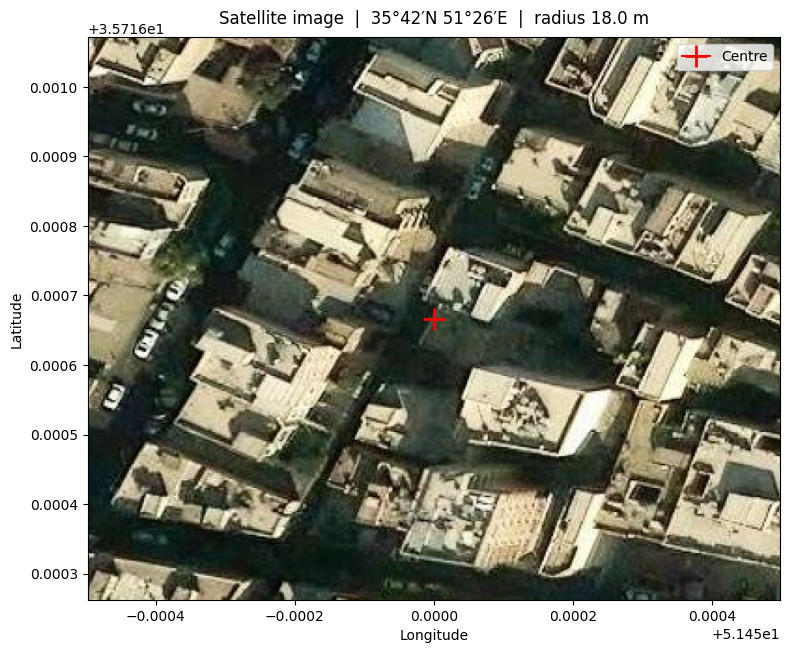

Image size : 371 × 372 px


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with rasterio.open(IMAGE_PATH) as src:
    img = src.read()          # shape: (bands, H, W)
    bounds = src.bounds

# Build RGB array — clamp and normalise to 0-1
rgb = np.stack([img[0], img[1], img[2]], axis=-1).astype(float)
rgb = np.clip(rgb / rgb.max(), 0, 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(
    rgb,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
)

# Mark the exact centre point
ax.plot(LONGITUDE, LATITUDE, marker="+", color="red",
        markersize=16, markeredgewidth=2, label="Centre")

ax.set_title(
    f"Satellite image  |  {LAT_STR} {LON_STR}  |  radius {RADIUS_M} m",
    fontsize=12, pad=10
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
print(f"Image size : {rgb.shape[1]} × {rgb.shape[0]} px")

## 12. Batch Processing

In [ ]:
def save_visualisation(image_path, masks_path, lat, lon, radius_m, west, east, north, south, output_path, title="Building count"):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import Ellipse
    import rasterio
    import numpy as np
    import math
    import os

    # 1. Open the background satellite image
    with rasterio.open(image_path) as src:
        rgb_arr = src.read()

    rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
    img_h, img_w = rgb.shape[:2]

    cx, cy = img_w / 2.0, img_h / 2.0
    mpp_y = (north - south) * 111_320 / img_h
    mpp_x = (east - west) * 111_320 * math.cos(math.radians(lat)) / img_w
    radius_px = radius_m / ((mpp_x + mpp_y) / 2.0)

    ys, xs = np.ogrid[:img_h, :img_w]
    circle_mask = ((xs - cx) ** 2 + (ys - cy) ** 2) <= radius_px ** 2

    overlay = rgb.copy()
    n_comp = n_part = n_out = 0

    # 2. SAFE CHECK: Only attempt to open the mask if it actually exists!
    if masks_path is not None and os.path.exists(masks_path):
        with rasterio.open(masks_path) as src:
            mask_arr = src.read(1).astype(np.int32)

        labels = np.unique(mask_arr); labels = labels[labels > 0]
        for label in labels:
            bld = mask_arr == label
            ins = int((bld & circle_mask).sum())
            tot = int(bld.sum())
            if ins == 0:
                color = np.array([1.0, 0.1, 0.1])
                n_out += 1
            elif ins == tot:
                color = np.array([0.1, 0.9, 0.1])
                n_comp += 1
            else:
                color = np.array([1.0, 0.85, 0.0])
                n_part += 1
            overlay[bld] = overlay[bld] * 0.4 + color * 0.6

    # 3. Draw the map, bounding circle, and legends
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(overlay, extent=[west, east, south, north], origin="upper")

    dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
    dlat = radius_m / 111_320
    ell = Ellipse(xy=(lon, lat), width=2*dlon, height=2*dlat,
                  edgecolor="cyan", facecolor="none", linewidth=2, linestyle="--")
    ax.add_patch(ell)
    ax.plot(lon, lat, "+", color="cyan", markersize=14, markeredgewidth=2)

    patches = [
        mpatches.Patch(color=(0.1, 0.9, 0.1), label=f"Completely inside ({n_comp})"),
        mpatches.Patch(color=(1.0, 0.85, 0.0), label=f"Partially inside ({n_part})"),
        mpatches.Patch(color=(1.0, 0.1, 0.1), label=f"Outside ({n_out})"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9)
    ax.set_title(f"{title}\nTotal={n_comp+n_part} | Complete={n_comp} | Partial={n_part}", fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout()

    # Save to disk
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

In [ ]:
TOLERANCE_FRACTION = 0.03

In [ ]:
# ── VISUALISATION 2 — outline-only borders + building numbers ─────────────
def visualise_counting_outlined(image_path, masks_path, lat, lon, radius_m,
                                 west, east, north, south,
                                 title="Building count (outlined)",
                                 tolerance_frac=TOLERANCE_FRACTION,
                                 font_size=7,
                                 contour_lw=1.5):
    """
    Clean satellite image with building OUTLINES only (no fill).
    """
    with rasterio.open(image_path) as src:
        rgb_arr = src.read()
        transform = src.transform
        bounds  = src.bounds
    rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
    img_h, img_w = rgb.shape[:2]

    with rasterio.open(masks_path) as src:
        mask_arr = src.read(1).astype(np.int32)

    circle_mask, r_px = _make_circle_mask(img_h, img_w, transform, lat, radius_m)
    cx, cy = img_w/2.0, img_h/2.0

    labels = np.unique(mask_arr); labels = labels[labels > 0]

    classified = []
    for lbl in labels:
        bld        = mask_arr == lbl
        total_px   = int(bld.sum())
        inside_px  = int((bld & circle_mask).sum())

        if inside_px == 0:
            cat = "outside"
        elif (total_px - inside_px) / total_px <= tolerance_frac:
            cat = "complete"
        else:
            cat = "partial"

        ys_idx, xs_idx = np.where(bld)
        cy_c = float(ys_idx.mean())
        cx_c = float(xs_idx.mean())
        classified.append((lbl, cat, cy_c, cx_c))

    c_counter = p_counter = 0
    numbered  = []
    for (lbl, cat, cy_c, cx_c) in classified:
        if cat == "complete":
            c_counter += 1; num = f"C-{c_counter}"; color = "#00e000"; txt_col = "black"
        elif cat == "partial":
            p_counter += 1; num = f"P-{p_counter}"; color = "#ffd700"; txt_col = "black"
        else:
            num = None;     color = "#888888";        txt_col = "white"
        numbered.append((lbl, cat, cy_c, cx_c, num, color, txt_col))

    fig, ax = plt.subplots(figsize=(11, 11))
    ax.imshow(rgb, extent=[west, east, south, north], origin="upper")

    geo_w = east - west
    geo_h = north - south

    for (lbl, cat, cy_c, cx_c, num, color, txt_col) in numbered:
        bld_mask_2d = (mask_arr == lbl).astype(np.uint8)
        contours = measure.find_contours(bld_mask_2d, 0.5)
        lw       = contour_lw if cat != "outside" else 0.8
        alpha    = 1.0        if cat != "outside" else 0.4

        for c in contours:
            c_lon = west  + c[:,1] / img_w * geo_w
            c_lat = north - c[:,0] / img_h * geo_h
            ax.plot(c_lon, c_lat, color=color, linewidth=lw, alpha=alpha)

        if num is not None:
            lbl_lon = west  + cx_c / img_w * geo_w
            lbl_lat = north - cy_c / img_h * geo_h
            ax.text(
                lbl_lon, lbl_lat, num,
                fontsize=font_size, color=txt_col, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.18", facecolor=color,
                          edgecolor="none", alpha=0.85),
                zorder=5,
            )

    dlon = radius_m/(111_320*math.cos(math.radians(lat)))
    dlat = radius_m/111_320
    ax.add_patch(Ellipse(xy=(lon,lat), width=2*dlon, height=2*dlat,
                         edgecolor="cyan", facecolor="none",
                         linewidth=2.2, linestyle="--", zorder=4))
    ax.plot(lon, lat, "+", color="cyan", markersize=14, markeredgewidth=2, zorder=4)

    n_comp = sum(1 for _,cat,*_ in numbered if cat=="complete")
    n_part = sum(1 for _,cat,*_ in numbered if cat=="partial")
    patches = [
        mpatches.Patch(color="#00e000", label=f"Completely inside ({n_comp})"),
        mpatches.Patch(color="#ffd700", label=f"Partially inside ({n_part})"),
        mpatches.Patch(color="#888888", label="Outside (no label)"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9, framealpha=0.85)
    ax.set_title(
        f"{title}\nTotal inside={n_comp+n_part}  |  C={n_comp} completely  |  P={n_part} partially",
        fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout(); plt.show()

print("\u2705 visualise_counting_outlined (border + numbers) ready")


✅ visualise_counting_outlined (border + numbers) ready


In [ ]:
from matplotlib.patches import Ellipse
# ── VISUALISATION 1 — filled overlay with colour-coded category ───────────
def visualise_counting(image_path, masks_path, lat, lon, radius_m,
                       west, east, north, south,
                       title="Building count",
                       tolerance_frac=TOLERANCE_FRACTION):
    """
    Satellite image + semi-transparent filled building masks.
    """
    with rasterio.open(image_path) as src:
        rgb_arr = src.read()
        transform = src.transform
    rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
    img_h, img_w = rgb.shape[:2]

    with rasterio.open(masks_path) as src:
        mask_arr = src.read(1).astype(np.int32)

    circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)
    labels = np.unique(mask_arr); labels = labels[labels > 0]

    overlay  = rgb.copy()
    n_comp = n_part = n_out = 0

    for label in labels:
        bld        = mask_arr == label
        total_px   = int(bld.sum())
        inside_px  = int((bld & circle_mask).sum())

        if inside_px == 0:
            color = np.array([1.0, 0.1, 0.1]); n_out += 1
        elif (total_px - inside_px) / total_px <= tolerance_frac:
            color = np.array([0.1, 0.9, 0.1]); n_comp += 1
        else:
            color = np.array([1.0, 0.85, 0.0]); n_part += 1

        overlay[bld] = overlay[bld]*0.35 + color*0.65

    fig, ax = plt.subplots(figsize=(9,9))
    ax.imshow(overlay, extent=[west, east, south, north], origin="upper")

    dlon = radius_m/(111_320*math.cos(math.radians(lat)))
    dlat = radius_m/111_320
    ax.add_patch(Ellipse(xy=(lon,lat), width=2*dlon, height=2*dlat,
                         edgecolor="cyan", facecolor="none", linewidth=2, linestyle="--"))
    ax.plot(lon, lat, "+", color="cyan", markersize=14, markeredgewidth=2)

    patches = [
        mpatches.Patch(color=(0.1,0.9,0.1), label=f"Completely inside ({n_comp})"),
        mpatches.Patch(color=(1.0,0.85,0.0), label=f"Partially inside ({n_part})"),
        mpatches.Patch(color=(1.0,0.1,0.1), label=f"Outside ({n_out})"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9)
    ax.set_title(f"{title}\nTotal={n_comp+n_part} | Complete={n_comp} | Partial={n_part}", fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout(); plt.show()

print("\u2705 visualise_counting (filled overlay) ready")


✅ visualise_counting (filled overlay) ready


In [ ]:
TOLERANCE_FRACTION = 0.03   # ← tune here: 0.03 means ≤3 % outside → "completely inside"

# def _make_circle_mask(img_h, img_w, lat, radius_m, west, east, north, south):
#     """Return a boolean pixel mask for the crater circle."""
#     cx, cy   = img_w / 2.0, img_h / 2.0
#     mpp_y    = (north - south) * 111_320 / img_h
#     mpp_x    = (east  - west ) * 111_320 * math.cos(math.radians(lat)) / img_w
#     r_px     = radius_m / ((mpp_x + mpp_y) / 2.0)
#     ys, xs   = np.ogrid[:img_h, :img_w]
#     return ((xs - cx)**2 + (ys - cy)**2) <= r_px**2, r_px

def count_buildings_in_radius(
    masks_path: str,
    lat: float,
    radius_m: float,
    west: float, east: float, north: float, south: float,
    tolerance_frac: float = TOLERANCE_FRACTION,
) -> tuple:
    """
    Count building segments completely or partially inside the crater circle.
    """
    with rasterio.open(masks_path) as src:
        mask_arr     = src.read(1).astype(np.int32)
        img_h, img_w = src.height, src.width
        transform    = src.transform

    circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)

    labels = np.unique(mask_arr)
    labels = labels[labels > 0]

    completely = partially = 0

    for label in labels:
        bld        = mask_arr == label
        total_px   = int(bld.sum())
        inside_px  = int((bld & circle_mask).sum())

        if inside_px == 0:
            continue

        outside_px = total_px - inside_px
        if outside_px / total_px <= tolerance_frac:
            completely += 1
        else:
            partially  += 1

    return completely + partially, completely, partially

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import numpy as np
import math
import os

# ── VISUALISATION 1 — filled overlay with colour-coded category ───────────
def visualise_counting(
    image_path, masks_path, lat, lon, radius_m,
    west, east, north, south,
    output_path,  # ✅ NEW (for saving PNG)
    title="Building count",
    tolerance_frac=TOLERANCE_FRACTION
):
    """
    Satellite image + semi-transparent filled building masks.
    Saves output as PNG.
    """

    # 1. Load image
    with rasterio.open(image_path) as src:
        rgb_arr = src.read()
        transform = src.transform

    rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
    img_h, img_w = rgb.shape[:2]

    overlay = rgb.copy()
    n_comp = n_part = n_out = 0

    # 2. Circle mask
    circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)

    # 3. SAFE mask loading
    if masks_path is not None and os.path.exists(masks_path):
        with rasterio.open(masks_path) as src:
            mask_arr = src.read(1).astype(np.int32)

        labels = np.unique(mask_arr)
        labels = labels[labels > 0]

        for label in labels:
            bld = (mask_arr == label)
            total_px = int(bld.sum())

            if total_px == 0:
                continue

            inside_px = int((bld & circle_mask).sum())

            if inside_px == 0:
                color = np.array([1.0, 0.1, 0.1])
                n_out += 1

            elif ((total_px - inside_px) / total_px) <= tolerance_frac:
                # ✅ tolerance applied here
                color = np.array([0.1, 0.9, 0.1])
                n_comp += 1

            else:
                color = np.array([1.0, 0.85, 0.0])
                n_part += 1

            overlay[bld] = overlay[bld] * 0.35 + color * 0.65

    # 4. Plot
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(overlay, extent=[west, east, south, north], origin="upper")

    dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
    dlat = radius_m / 111_320

    ax.add_patch(Ellipse(
        xy=(lon, lat),
        width=2 * dlon,
        height=2 * dlat,
        edgecolor="cyan",
        facecolor="none",
        linewidth=2,
        linestyle="--"
    ))

    ax.plot(lon, lat, "+", color="cyan", markersize=14, markeredgewidth=2)

    patches = [
        mpatches.Patch(color=(0.1, 0.9, 0.1), label=f"Completely inside ({n_comp})"),
        mpatches.Patch(color=(1.0, 0.85, 0.0), label=f"Partially inside ({n_part})"),
        mpatches.Patch(color=(1.0, 0.1, 0.1), label=f"Outside ({n_out})"),
    ]

    ax.legend(handles=patches, loc="upper right", fontsize=9)

    ax.set_title(
        f"{title}\nTotal={n_comp+n_part} | Complete={n_comp} | Partial={n_part}",
        fontsize=11
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()

    # ✅ 5. SAVE PNG
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    return output_path


print("✅ visualise_counting (PNG + tolerance) ready")

✅ visualise_counting (PNG + tolerance) ready


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import rasterio
import numpy as np
import math
import os
from skimage import measure

def visualise_counting_outlined(
    image_path, masks_path, lat, lon, radius_m,
    west, east, north, south,
    output_path,
    title="Building count (outlined)",
    tolerance_frac=TOLERANCE_FRACTION,
    font_size=9,              # 🔥 bigger text
    contour_lw=2.8            # 🔥 thicker lines
):

    with rasterio.open(image_path) as src:
        rgb_arr = src.read()
        transform = src.transform

    rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
    img_h, img_w = rgb.shape[:2]

    circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)

    classified = []

    if masks_path is not None and os.path.exists(masks_path):
        with rasterio.open(masks_path) as src:
            mask_arr = src.read(1).astype(np.int32)

        labels = np.unique(mask_arr)
        labels = labels[labels > 0]

        for lbl in labels:
            bld = (mask_arr == lbl)
            total_px = int(bld.sum())
            if total_px == 0:
                continue

            inside_px = int((bld & circle_mask).sum())

            if inside_px == 0:
                cat = "outside"
            elif ((total_px - inside_px) / total_px) <= tolerance_frac:
                cat = "complete"
            else:
                cat = "partial"

            ys_idx, xs_idx = np.where(bld)
            cy_c = float(ys_idx.mean())
            cx_c = float(xs_idx.mean())

            classified.append((lbl, cat, cy_c, cx_c, bld))

    c_counter = p_counter = 0
    numbered = []

    for (lbl, cat, cy_c, cx_c, bld) in classified:
        if cat == "complete":
            c_counter += 1
            num = f"C-{c_counter}"
            color = "#00ff00"   # brighter green
        elif cat == "partial":
            p_counter += 1
            num = f"P-{p_counter}"
            color = "#ffcc00"   # brighter yellow
        else:
            num = None
            color = "#aaaaaa"   # lighter grey

        numbered.append((lbl, cat, cy_c, cx_c, num, color, bld))

    fig, ax = plt.subplots(figsize=(11, 11))
    ax.imshow(rgb, extent=[west, east, south, north], origin="upper")

    geo_w = east - west
    geo_h = north - south

    for (lbl, cat, cy_c, cx_c, num, color, bld_mask) in numbered:

        bld_mask_2d = bld_mask.astype(np.uint8)
        contours = measure.find_contours(bld_mask_2d, 0.5)

        lw = contour_lw if cat != "outside" else 1.5   # 🔥 thicker outside too
        alpha = 1.0 if cat != "outside" else 0.5

        for c in contours:
            c_lon = west + c[:, 1] / img_w * geo_w
            c_lat = north - c[:, 0] / img_h * geo_h
            ax.plot(c_lon, c_lat, color=color, linewidth=lw, alpha=alpha)

        if num is not None:
            lbl_lon = west + cx_c / img_w * geo_w
            lbl_lat = north - cy_c / img_h * geo_h

            txt = ax.text(
                lbl_lon, lbl_lat, num,
                fontsize=font_size,
                color="black",
                ha="center", va="center",
                weight="bold",  # 🔥 bold text
                bbox=dict(
                    boxstyle="round,pad=0.3",   # 🔥 more padding
                    facecolor=color,
                    edgecolor="black",
                    linewidth=0.8,
                    alpha=0.95                 # 🔥 more solid
                ),
                zorder=5,
            )

            # 🔥 White outline around text (VERY effective)
            txt.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='white'),
                path_effects.Normal()
            ])

    dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
    dlat = radius_m / 111_320

    ax.add_patch(Ellipse(
        xy=(lon, lat),
        width=2 * dlon,
        height=2 * dlat,
        edgecolor="cyan",
        facecolor="none",
        linewidth=3.0,   # 🔥 thicker circle
        linestyle="--",
        zorder=4
    ))

    ax.plot(lon, lat, "+", color="cyan", markersize=16, markeredgewidth=2.5, zorder=4)

    n_comp = sum(1 for _, cat, *_ in numbered if cat == "complete")
    n_part = sum(1 for _, cat, *_ in numbered if cat == "partial")

    patches = [
        mpatches.Patch(color="#00ff00", label=f"Completely inside ({n_comp})"),
        mpatches.Patch(color="#ffcc00", label=f"Partially inside ({n_part})"),
        mpatches.Patch(color="#aaaaaa", label="Outside (no label)"),
    ]

    ax.legend(handles=patches, loc="upper right", fontsize=10, framealpha=0.9)

    ax.set_title(
        f"{title}\nTotal inside={n_comp+n_part}  |  C={n_comp}  |  P={n_part}",
        fontsize=13
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)

    return output_path


print("✅ visualise_counting_outlined (thicker + clearer) ready")

✅ visualise_counting_outlined (thicker + clearer) ready


In [ ]:
# import os
# import pandas as pd

# BATCH_PROMPT = "building"
# BATCH_OUTPUT_DIR = "crater_analysis"
# VIS_OUTPUT_DIR = "crater_visualisations"
# VLM_CROP_DIR = "vlm_grid_outputs"

# os.makedirs(BATCH_OUTPUT_DIR, exist_ok=True)
# os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)
# os.makedirs(VLM_CROP_DIR, exist_ok=True)

# batch_results = []

# for idx, row in df[["max_crater_radius_m", "lat_dec", "lon_dec"]].iterrows():
#     lat = float(row["lat_dec"])
#     lon = float(row["lon_dec"])
#     radius_m = float(row["max_crater_radius_m"])

#     print(f"\n{'='*62}\nRow {idx} | lat={lat:.5f} lon={lon:.5f} radius={radius_m:,.0f}m")
#     record = {"index": idx, "lat": lat, "lon": lon, "max_crater_radius_m": radius_m}

#     try:
#         # 1. Paths for both imagery sources
#         esri_img_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_esri_image.tif")
#         google_img_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_google_image.tif")
#         esri_masks_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_esri_masks.tif")
#         google_masks_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_google_masks.tif")

#         # 2. Download Base Imagery (ESRI & Google)
#         zoom = optimal_zoom_for_radius(radius_m, lat, verbose=True)

#         # ESRI Download
#         _, (w_e, s_e, e_e, n_e) = download_esri_geotiff(lat, lon, radius_m, zoom, esri_img_path, padding_factor=2.5)
#         # Google Download (Ensure your download function supports provider switching or has a google equivalent)
#         _, (w_g, s_g, e_g, n_g) = download_google_geotiff(lat, lon, radius_m, zoom, google_img_path, padding_factor=2.5)

#         # 3. Generate Masks for both sources
#         # Process ESRI
#         sam3.set_image(esri_img_path)
#         sam3.generate_masks(prompt=BATCH_PROMPT)
#         sam3.save_masks(output=esri_masks_path, unique=True)

#         # Process Google
#         sam3.set_image(google_img_path)
#         sam3.generate_masks(prompt=BATCH_PROMPT)
#         sam3.save_masks(output=google_masks_path, unique=True)

#         # 4. Generate the VLM Master Grids (The decision-makers)
#         grid_2p_path = os.path.join(VLM_CROP_DIR, f"row_{idx}_vlm_2panel.jpg")
#         grid_4p_path = os.path.join(VLM_CROP_DIR, f"row_{idx}_vlm_4panel_depth.jpg")

#         # Call the 2-Panel (Blob vs Split)
#         generate_vlm_batch_grid_2panel(
#             esri_img_path, google_img_path,
#             esri_masks_path, google_masks_path,
#             lat, radius_m, output_path=grid_2p_path
#         )

#         # Call the 4-Panel (Depth Gradient)
#         generate_vlm_batch_grid_4panel_gradient(
#             esri_img_path, google_img_path,
#             esri_masks_path, google_masks_path,
#             lat, radius_m, output_path=grid_4p_path
#         )

#         # 5. Calculation for deterministic baseline
#         total, complete, partial = count_buildings_in_radius(google_masks_path, lat, radius_m, w_g, e_g, n_g, s_g)
#         record.update({"total": total, "complete": complete, "partial": partial, "error": None})

#         print(f"  → Deterministic Count: {total} | Grids saved to {VLM_CROP_DIR}")

#     except Exception as exc:
#         record.update({"total": 0, "error": str(exc)})
#         print(f"  [ERR] Row {idx} Failed: {exc}")

#     batch_results.append(record)

# # Convert to DataFrame and save
# results_df = pd.DataFrame(batch_results)
# results_df.to_csv("crater_batch_results.csv", index=False)

In [ ]:
# BATCH_PROMPT = "building, structure"
# BATCH_OUTPUT_DIR = "crater_analysis"
# VIS_OUTPUT_DIR = "crater_visualisations"

# os.makedirs(BATCH_OUTPUT_DIR, exist_ok=True)
# os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)

# batch_results = []

# for idx, row in df[["max_crater_radius_m", "lat_dec", "lon_dec"]].iterrows():
#   lat = float(row["lat_dec"])
#   lon = float(row["lon_dec"])
#   radius_m = float(row["max_crater_radius_m"])

#   print(f"\n{'='*62}\nRow {idx} | lat={lat:.5f} lon={lon:.5f} radius={radius_m:,.0f}m")

#   record = {"index": idx, "lat": lat, "lon": lon, "max_crater_radius_m": radius_m}

#   try:
#       # 1. Download base imagery
#       zoom = optimal_zoom_for_radius(radius_m, lat, verbose=True)
#       img_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_image.tif")
#       masks_path = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_masks.tif")
#       vis_path = os.path.join(VIS_OUTPUT_DIR, f"row_{idx}_vis.png")
#       vis_path_2 = os.path.join(VIS_OUTPUT_DIR, f"row_{idx}_outlined_vis.png")

#       _, (west, south, east, north) = download_google_geotiff(lat, lon, radius_m, zoom, img_path, verbose=True,padding_factor=3)

#       # 2. Try to extract masks
#       total, complete, partial = 0, 0, 0
#       try:
#           sam3.set_image(img_path)
#           sam3.generate_masks(prompt=BATCH_PROMPT)
#           sam3.save_masks(output=masks_path, unique=True)
#           total, complete, partial = count_buildings_in_radius(masks_path, lat, radius_m, west, east, north, south)
#       except Exception as sam_exc:
#           print(f"  [WARN] SAM3 found no masks or failed: {sam_exc}")
#           masks_path = None # Force visualization to skip masks but still draw the image and circle

#       record.update({"total": total, "complete": complete, "partial": partial, "error": None})

#       # 3. ALWAYS save visualization (because we successfully got the image)
#       visualise_counting(img_path, masks_path, lat, lon, radius_m, west, east, north, south, vis_path, title=f"Row {idx}")
#       visualise_counting_outlined(img_path, masks_path, lat, lon, radius_m, west, east, north, south, vis_path_2, title=f"Row {idx} Outlined")

#       print(f"  → {total} buildings | {complete} complete | {partial} partial")
#       print(f"  → Saved image: {vis_path}")

#   except Exception as exc:
#       # 4. This outer block ONLY triggers if the image fails to download/stitch
#       record.update({"total": 0, "complete": 0, "partial": 0, "error": str(exc)})
#       print(f"  [ERR] Download/Processing Failed: {exc} -> Setting counts to 0")

#   batch_results.append(record)

### Comparison Visualization

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import rasterio
import numpy as np
import math
import os
from skimage import measure


def visualise_comparison_outlined(
    google_img_path, google_masks_path,
    esri_img_path, esri_masks_path,
    lat, lon, radius_m,
    west, east, north, south,
    output_path,
    title="Google vs Esri Comparison",
    tolerance_frac=TOLERANCE_FRACTION,
    font_size=10,
    contour_lw=3.8
):

    def process_one(ax, image_path, masks_path, label_name):

        # ---------------- LOAD IMAGE ----------------
        with rasterio.open(image_path) as src:
            rgb_arr = src.read()
            transform = src.transform

        rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
        rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
        img_h, img_w = rgb.shape[:2]

        ax.imshow(rgb, extent=[west, east, south, north], origin="upper")

        # ---------------- REMOVE AXES ----------------
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")

        # ---------------- TOP LABEL ----------------
        ax.text(
            0.5, 1.02,
            label_name,
            transform=ax.transAxes,
            fontsize=14,
            weight="bold",
            ha="center",
            va="bottom",
            color="white",
            bbox=dict(facecolor="black", alpha=0.8, pad=4, edgecolor="none")
        )

        # ---------------- CIRCLE ----------------
        dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
        dlat = radius_m / 111_320

        ax.add_patch(Ellipse(
            xy=(lon, lat),
            width=2 * dlon,
            height=2 * dlat,
            edgecolor="cyan",
            facecolor="none",
            linewidth=3.2,
            linestyle="--",
            zorder=4
        ))

        ax.plot(lon, lat, "+", color="cyan", markersize=16, markeredgewidth=2.5, zorder=4)

        # ---------------- MASK HANDLING ----------------
        classified = []

        if masks_path is not None and os.path.exists(masks_path):

            with rasterio.open(masks_path) as src:
                mask_arr = src.read(1).astype(np.int32)

            circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)

            labels = np.unique(mask_arr)
            labels = labels[labels > 0]

            for lbl in labels:
                bld = (mask_arr == lbl)

                total_px = int(bld.sum())
                if total_px == 0:
                    continue

                inside_px = int((bld & circle_mask).sum())

                if inside_px == 0:
                    cat = "outside"
                elif ((total_px - inside_px) / total_px) <= tolerance_frac:
                    cat = "complete"
                else:
                    cat = "partial"

                ys_idx, xs_idx = np.where(bld)
                cy_c = float(ys_idx.mean())
                cx_c = float(xs_idx.mean())

                classified.append((cat, cy_c, cx_c, bld))

        # ---------------- LABELING ----------------
        c_counter = 0
        p_counter = 0

        geo_w = east - west
        geo_h = north - south

        for (cat, cy_c, cx_c, bld_mask) in classified:

            if cat == "complete":
                c_counter += 1
                num = f"C-{c_counter}"   # ✅ cleaned
                color = "#00ff00"
            elif cat == "partial":
                p_counter += 1
                num = f"P-{p_counter}"   # ✅ cleaned
                color = "#ffcc00"
            else:
                num = None
                color = "#aaaaaa"

            # ---------------- CONTOURS ----------------
            contours = measure.find_contours(bld_mask.astype(np.uint8), 0.5)

            for c in contours:
                c_lon = west + c[:, 1] / img_w * geo_w
                c_lat = north - c[:, 0] / img_h * geo_h

                ax.plot(
                    c_lon, c_lat,
                    color=color,
                    linewidth=contour_lw,
                    alpha=1.0,
                    solid_joinstyle="round"
                )

            # ---------------- LABEL TEXT ----------------
            if num is not None:
                lbl_lon = west + cx_c / img_w * geo_w
                lbl_lat = north - cy_c / img_h * geo_h

                txt = ax.text(
                    lbl_lon, lbl_lat, num,
                    fontsize=font_size - 2,   # ✅ smaller
                    color="black",
                    ha="center", va="center",
                    weight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",   # ✅ tighter
                        facecolor=color,
                        edgecolor="black",
                        linewidth=1.0,
                        alpha=0.95
                    ),
                    zorder=6
                )

                txt.set_path_effects([
                    path_effects.Stroke(linewidth=2.0, foreground='white'),  # ✅ lighter
                    path_effects.Normal()
                ])

        return c_counter, p_counter


    # ==========================================================
    # FIGURE
    # ==========================================================
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(1, 2, wspace=0.02)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    g_c, g_p = process_one(ax1, google_img_path, google_masks_path, "GOOGLE")
    e_c, e_p = process_one(ax2, esri_img_path, esri_masks_path, "ESRI")

    # ---------------- LEGEND ----------------
    patches = [
        mpatches.Patch(color="#00ff00", label="Complete"),
        mpatches.Patch(color="#ffcc00", label="Partial"),
    ]

    ax2.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.85)

    # ---------------- TITLE ----------------
    fig.suptitle(
        f"{title} | G:{g_c+g_p}  E:{e_c+e_p}",
        fontsize=13
    )

    plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.02)

    plt.savefig(output_path, dpi=180, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)

    return output_path


print("✅ Updated comparison visualization ready")

✅ Updated comparison visualization ready


### Helper Functions

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from skimage import measure
from scipy.ndimage import distance_transform_edt
import cv2
import torch
from transformers import pipeline
from PIL import Image


def _prepare_rgb(src):
    rgb_arr = src.read()
    if rgb_arr.shape[0] < 3:
        rgb = np.stack([rgb_arr[0]]*3, axis=-1).astype(float)
    else:
        rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
    return np.clip(rgb / max(rgb.max(), 1), 0, 1)


def match_esri_to_google_spatially(esri_masks_path, google_masks_path):

    with rasterio.open(google_masks_path) as g_src:
        g_arr = g_src.read(1).astype(np.int32)
        g_transform = g_src.transform
        g_crs = g_src.crs

    with rasterio.open(esri_masks_path) as e_src:
        e_raw = e_src.read(1).astype(np.int32)
        e_aligned = np.zeros_like(g_arr)

        reproject(
            source=e_raw,
            destination=e_aligned,
            src_transform=e_src.transform,
            src_crs=e_src.crs,
            dst_transform=g_transform,
            dst_crs=g_crs,
            resampling=Resampling.nearest
        )

    google_to_esri = {}
    esri_to_google = {}

    for e_label in np.unique(e_aligned):
        if e_label == 0:
            continue

        mask = (e_aligned == e_label)
        overlap = g_arr[mask]
        overlap = overlap[overlap > 0]

        if len(overlap) == 0:
            esri_to_google[e_label] = None
            continue

        g_label = np.bincount(overlap).argmax()
        esri_to_google[e_label] = g_label

        google_to_esri.setdefault(g_label, []).append(e_label)

    return esri_to_google, google_to_esri

### Depth Model

In [ ]:
print("Loading Depth model...")
depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf",
    device=0 if torch.cuda.is_available() else -1
)

def get_depth_gradient_map(rgb):
    img = (rgb * 255).astype(np.uint8)
    depth = depth_estimator(Image.fromarray(img))["depth"]
    depth = np.array(depth)

    depth_norm = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    depth_col = cv2.applyColorMap(depth_norm, cv2.COLORMAP_INFERNO)
    depth_rgb = cv2.cvtColor(depth_col, cv2.COLOR_BGR2RGB)

    return depth_rgb / 255.0

Loading Depth model...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [ ]:
def _make_circle_mask(img_h, img_w, transform, lat, radius_m, lon=None):
    """
    Return a boolean pixel mask for the crater circle, respecting transform.
    Uses the geotransform to locate the true pixel center of the target point.
    """
    mpp_y = abs(transform.e) * 111_320
    mpp_x = abs(transform.a) * 111_320 * math.cos(math.radians(lat))
    r_px = radius_m / ((mpp_x + mpp_y) / 2.0)

    # ── Use geotransform to find exact pixel center ──────────────────────
    # transform.c = west bound (lon of pixel 0,0 left edge)
    # transform.f = north bound (lat of pixel 0,0 top edge)
    # transform.a = pixel width in degrees, transform.e = pixel height (negative)
    if lon is not None:
        cx_px = (lon - transform.c) / transform.a
        cy_px = (lat - transform.f) / transform.e
        # Clamp to image bounds as a safety net
        cx_px = max(0.0, min(img_w - 1.0, cx_px))
        cy_px = max(0.0, min(img_h - 1.0, cy_px))
    else:
        # Fallback: assume symmetric bbox (target at image center)
        cx_px, cy_px = img_w / 2.0, img_h / 2.0

    ys, xs = np.ogrid[:img_h, :img_w]
    mask = ((xs - cx_px)**2 + (ys - cy_px)**2) <= r_px**2

    return mask, r_px

### 4 panel

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
from transformers import pipeline
from PIL import Image
from skimage import measure
from scipy.ndimage import distance_transform_edt

# ---------------- DEPTH MODEL ----------------
print("Loading Depth Anything model...")
depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf",
    device=0 if torch.cuda.is_available() else -1
)

def get_depth_gradient_map(rgb_crop_array):
    img_uint8 = (rgb_crop_array * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)

    depth_output = depth_estimator(pil_image)
    depth_array = np.array(depth_output["depth"])

    depth_norm = cv2.normalize(depth_array, None, 0, 255,
                               cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    depth_colormap = cv2.applyColorMap(depth_norm, cv2.COLORMAP_INFERNO)
    depth_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

    return depth_rgb / 255.0



Loading Depth Anything model...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [ ]:
def generate_vlm_batch_grid_4panel_gradient(
    esri_rgb_path, google_rgb_path,
    esri_masks_path, google_masks_path,
    lat, radius_m,
    pad=20,
    output_path='vlm_master_grid_4panel_depth.jpg'
):

    print("Generating 4-Panel Grid with Depth Gradients (UNION MODE + LABELS)...")

    import rasterio
    from rasterio.warp import reproject, Resampling
    import numpy as np
    import matplotlib.pyplot as plt
    from skimage import measure
    from scipy.ndimage import distance_transform_edt
    import os

    # ---------------- LABEL FORMATTER ----------------
    def format_label(label_id, source):
        # 🔥 Customize this logic if needed
        if source == "google":
            prefix = "P"   # Primary / Google
        else:
            prefix = "C"   # Cluster / ESRI
        return f"{prefix}-{label_id}"

    # ---------------- LOAD ----------------
    with rasterio.open(google_rgb_path) as src_g:
        google_rgb = _prepare_rgb(src_g)
        google_transform = src_g.transform
        google_crs = src_g.crs

    google_mask_arr = None
    if google_masks_path and os.path.exists(google_masks_path):
        with rasterio.open(google_masks_path) as src_gm:
            google_mask_arr = src_gm.read(1).astype(np.int32)

    with rasterio.open(esri_rgb_path) as src_e:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    esri_raw_mask_arr = None
    if esri_masks_path and os.path.exists(esri_masks_path):
        with rasterio.open(esri_masks_path) as src_em:
            esri_raw_mask_arr = src_em.read(1).astype(np.int32)

    # ---------------- REPROJECT ESRI MASK → GOOGLE GRID ----------------
    if esri_raw_mask_arr is not None:
        esri_mask_on_google = np.zeros_like(
            google_mask_arr if google_mask_arr is not None else google_rgb[:, :, 0],
            dtype=np.int32
        )

        reproject(
            source=esri_raw_mask_arr,
            destination=esri_mask_on_google,
            src_transform=esri_raw_transform,
            src_crs=esri_raw_crs,
            dst_transform=google_transform,
            dst_crs=google_crs,
            resampling=Resampling.nearest
        )
    else:
        esri_mask_on_google = None

    # ---------------- CIRCLE ----------------
    google_h, google_w = google_rgb.shape[:2]

    google_circle, google_r = _make_circle_mask(
        google_h, google_w, google_transform, lat, radius_m
    )

    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    # ---------------- TERRITORY ----------------
    if google_mask_arr is not None:
        bg_mask_g = (google_mask_arr == 0)
        _, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
        google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]
    else:
        google_territory_arr = np.zeros((google_h, google_w), dtype=np.int32)

    # ==================================================
    # 🔥 UNION TARGETS
    # ==================================================
    targets = []

    if google_mask_arr is not None:
        for g in np.unique(google_mask_arr):
            if g == 0:
                continue
            mask = (google_mask_arr == g)
            if np.any(mask & google_circle):
                targets.append(("google", g))

    if esri_mask_on_google is not None:
        for e in np.unique(esri_mask_on_google):
            if e == 0:
                continue

            mask = (esri_mask_on_google == e)

            if not np.any(mask & google_circle):
                continue

            overlap = False
            if google_mask_arr is not None:
                overlap = np.any(mask & (google_mask_arr > 0))

            if not overlap:
                targets.append(("esri_only", e))

    if len(targets) == 0:
        print("[SKIP] No detections")
        return

    print(f"Compiling {len(targets)} targets...")

    # ---------------- FIGURE ----------------
    fig, axes = plt.subplots(
        nrows=len(targets),
        ncols=4,
        figsize=(26, 5 * len(targets)),
        squeeze=False
    )
    fig.patch.set_facecolor('#111111')

    # ==================================================
    # MAIN LOOP
    # ==================================================
    for idx, (source_type, label_id) in enumerate(targets):

        if source_type == "google":
            mask_full = (google_mask_arr == label_id)
        else:
            mask_full = (esri_mask_on_google == label_id)

        if not np.any(mask_full):
            continue

        ys, xs = np.where(mask_full)

        y_min = max(0, ys.min() - pad)
        y_max = min(google_h, ys.max() + pad)
        x_min = max(0, xs.min() - pad)
        x_max = min(google_w, xs.max() + pad)

        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()

        # ---------------- ESRI RGB ALIGN ----------------
        crop_h, crop_w = crop_rgb_g.shape[:2]
        crop_rgb_e = np.zeros((crop_h, crop_w, 3))

        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        dst_transform_crop = rasterio.Affine(
            google_transform.a, google_transform.b, west_g,
            google_transform.d, google_transform.e, north_g
        )

        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band],
                destination=crop_rgb_e[:, :, band],
                src_transform=esri_raw_transform,
                src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop,
                dst_crs=google_crs,
                resampling=Resampling.bilinear
            )

        # ---------------- DEPTH ----------------
        try:
            depth_grad_g = get_depth_gradient_map(crop_rgb_g)
            depth_grad_e = get_depth_gradient_map(crop_rgb_e)
        except Exception as e:
            print(f"[WARN] Depth failed: {e}")
            continue

        # ---------------- DIM ----------------
        crop_circle = google_circle[y_min:y_max, x_min:x_max]
        dim_mask = (~crop_circle)

        crop_rgb_g[dim_mask] *= 0.4
        crop_rgb_e[dim_mask] *= 0.4
        depth_grad_g[dim_mask] *= 0.4
        depth_grad_e[dim_mask] *= 0.4

        # ==================================================
        # 🔥 LABEL EXTRACTION (KEY PART)
        # ==================================================
        g_labels = []
        e_labels = []

        if google_mask_arr is not None:
            g_crop = google_mask_arr[y_min:y_max, x_min:x_max]
            for g in np.unique(g_crop):
                if g == 0:
                    continue
                g_labels.append(format_label(g, "google"))

        if esri_mask_on_google is not None:
            e_crop = esri_mask_on_google[y_min:y_max, x_min:x_max]
            for e in np.unique(e_crop):
                if e == 0:
                    continue
                e_labels.append(format_label(e, "esri"))

        g_labels = sorted(list(set(g_labels)))
        e_labels = sorted(list(set(e_labels)))

        label_text = ""
        if g_labels:
            label_text += "G[" + ", ".join(g_labels) + "]"
        if e_labels:
            if label_text:
                label_text += " | "
            label_text += "E[" + ", ".join(e_labels) + "]"

        # ---------------- PLOT ----------------
        ax_g, ax_e, ax_dg, ax_de = axes[idx]

        cx_crop = cx_full - x_min
        cy_crop = cy_full - y_min

        circle_style = dict(radius=google_r, color='#33ffff',
                            fill=False, linewidth=3, linestyle='--')

        # GOOGLE
        ax_g.imshow(crop_rgb_g)
        ax_g.axis('off')
        ax_g.set_title(f"Target {idx+1}: {label_text}", color='yellow')
        ax_g.add_artist(plt.Circle((cx_crop, cy_crop), **circle_style))

        # ESRI
        ax_e.imshow(crop_rgb_e)
        ax_e.axis('off')
        ax_e.set_title("ESRI View", color='#00ff00')
        ax_e.add_artist(plt.Circle((cx_crop, cy_crop), **circle_style))

        # DEPTH
        ax_dg.imshow(depth_grad_g)
        ax_dg.axis('off')
        ax_dg.set_title("Google Depth", color='magenta')

        ax_de.imshow(depth_grad_e)
        ax_de.axis('off')
        ax_de.set_title("ESRI Depth", color='magenta')

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, facecolor=fig.get_facecolor())
    plt.close(fig)

    print(f"✅ Saved → {output_path}")

## Code for 2 panel (Seg-Augmented Images) and 4 panel (depth augmented image)

### 2 panel (Seg-Augmented Images)
###  4 panel (depth augmented image)

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from skimage import measure
from scipy.ndimage import distance_transform_edt
from transformers import pipeline
from PIL import Image

# ==============================================================================
# 1. INITIALIZE DEPTH MODEL (Run once globally to save VRAM/Time)
# ==============================================================================
print("Loading Depth Anything model...")
depth_estimator = pipeline(
    task="depth-estimation",
    model="LiheYoung/depth-anything-small-hf",
    device=0 if torch.cuda.is_available() else -1
)

def get_depth_gradient_map(rgb_crop_array):
    """
    Runs Depth Anything on an RGB crop and returns a colored depth heatmap.
    Bright Yellow = Highest Elevation, Dark Purple/Black = Lowest Elevation.
    """
    img_uint8 = (rgb_crop_array * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)

    depth_output = depth_estimator(pil_image)
    depth_array = np.array(depth_output["depth"])

    # Normalize depth map to 0-255
    depth_norm = cv2.normalize(depth_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Apply the INFERNO colormap (Great for visualizing depth/heat)
    depth_colormap = cv2.applyColorMap(depth_norm, cv2.COLORMAP_INFERNO)

    # Convert BGR (OpenCV default) to RGB (Matplotlib default)
    depth_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

    return depth_rgb / 255.0

# ==============================================================================
# 2. THE 2-PANEL GRID GENERATOR (Blob vs Splits)
# ==============================================================================
def generate_vlm_batch_grid_2panel(esri_rgb_path, google_rgb_path, esri_masks_path, google_masks_path, lat, radius_m, pad=20, output_path='vlm_master_grid_2panel.jpg'):
    print("Generating Optimized 2-Panel VLM Master Grid...")

    with rasterio.open(google_rgb_path) as src_g, rasterio.open(google_masks_path) as src_gm:
        google_rgb = _prepare_rgb(src_g)
        google_mask_arr = src_gm.read(1).astype(np.int32)
        google_transform = src_g.transform
        google_crs = src_g.crs

    with rasterio.open(esri_rgb_path) as src_e, rasterio.open(esri_masks_path) as src_em:
        esri_raw_rgb = _prepare_rgb(src_e)
        esri_raw_mask_arr = src_em.read(1).astype(np.int32)
        esri_raw_transform = src_e.transform
        esri_raw_crs = src_e.crs

    _, google_to_esri_map = match_esri_to_google_spatially(esri_masks_path, google_masks_path)

    google_h, google_w = google_rgb.shape[:2]
    google_circle, google_r = _make_circle_mask(google_h, google_w, google_transform, lat, radius_m)
    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    bg_mask_g = (google_mask_arr == 0)
    distances_g, indices_g = distance_transform_edt(bg_mask_g, return_indices=True)
    google_territory_arr = google_mask_arr[indices_g[0], indices_g[1]]

    valid_g_labels = [g for g in sorted(list(google_to_esri_map.keys()))
                      if int(((google_mask_arr == g) & google_circle).sum()) > 0]

    n_targets = len(valid_g_labels)
    if n_targets == 0:
        print("No intersecting structures found.")
        return

    fig, axes = plt.subplots(nrows=n_targets, ncols=2, figsize=(14, 5 * n_targets), squeeze=False)
    fig.patch.set_facecolor('#111111')

    for idx, g_label in enumerate(valid_g_labels):
        bld_mask_2d_g = (google_mask_arr == g_label)
        ys, xs = np.where(bld_mask_2d_g)

        y_min, y_max = max(0, ys.min() - pad), min(google_h, ys.max() + pad)
        x_min, x_max = max(0, xs.min() - pad), min(google_w, xs.max() + pad)

        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_territory_g = google_territory_arr[y_min:y_max, x_min:x_max]
        crop_circle_g = google_circle[y_min:y_max, x_min:x_max]

        dim_mask = (crop_territory_g != g_label) | (~crop_circle_g)
        crop_rgb_g[dim_mask] = crop_rgb_g[dim_mask] * 0.4

        matched_esris = google_to_esri_map[g_label]
        west_g, south_g = google_transform * (x_min, y_max)
        east_g, north_g = google_transform * (x_max, y_min)

        crop_aligned_h, crop_aligned_w = y_max - y_min, x_max - x_min
        dst_transform_crop = rasterio.Affine(google_transform.a, google_transform.b, west_g,
                                             google_transform.d, google_transform.e, north_g)

        crop_rgb_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w, 3))
        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band], destination=crop_rgb_e_aligned[:, :, band],
                src_transform=esri_raw_transform, src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.bilinear
            )

        crop_mask_arr_e_aligned = np.zeros((crop_aligned_h, crop_aligned_w), dtype=np.int32)
        reproject(
            source=esri_raw_mask_arr, destination=crop_mask_arr_e_aligned,
            src_transform=esri_raw_transform, src_crs=esri_raw_crs,
            dst_transform=dst_transform_crop, dst_crs=google_crs, resampling=Resampling.nearest
        )

        crop_rgb_e_aligned[dim_mask] = crop_rgb_e_aligned[dim_mask] * 0.4

        ax_g = axes[idx, 0]
        ax_e = axes[idx, 1]
        cx_crop, cy_crop = cx_full - x_min, cy_full - y_min

        ax_g.imshow(crop_rgb_g, origin='upper')
        ax_g.set_title(f"Target {idx + 1}: Continuous Blob", fontweight='bold', color='yellow', fontsize=14)
        circ_g = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_g.add_artist(circ_g)

        contours_g = measure.find_contours(bld_mask_2d_g[y_min:y_max, x_min:x_max], 0.5)
        for contour in contours_g:
            ax_g.plot(contour[:, 1], contour[:, 0], color='#ffff00', linewidth=3.5)
        ax_g.axis('off')

        ax_e.imshow(crop_rgb_e_aligned, origin='upper')
        ax_e.set_title(f"Target {idx + 1}: Height Divisions", fontweight='bold', color='#00ff00', fontsize=14)
        circ_e = plt.Circle((cx_crop, cy_crop), google_r, color='#33ffff', fill=False, linewidth=2, linestyle='--', alpha=0.9)
        ax_e.add_artist(circ_e)

        for e_label in matched_esris:
            e_bld_mask = (crop_mask_arr_e_aligned == e_label)
            contours_e = measure.find_contours(e_bld_mask, 0.5)
            for contour in contours_e:
                ax_e.plot(contour[:, 1], contour[:, 0], color='#00ffff', linewidth=3.5)
        ax_e.axis('off')

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)
    print(f"✅ Saved 2-panel grid to {output_path}")

# ==============================================================================
# 3. THE 4-PANEL GRID GENERATOR (With Pure Depth & Strict Dimming)
# ==============================================================================
def generate_vlm_batch_grid_4panel_gradient(
    esri_rgb_path, google_rgb_path,
    esri_masks_path, google_masks_path,
    lat, radius_m,
    pad=20,
    output_path='vlm_master_grid_4panel_depth.jpg',
    tolerance_frac=0.1 # Replace with your TOLERANCE_FRACTION variable
):
    print("Generating 4-Panel Grid (per-source spotlight + comparison-matched labels)...")

    # ── 1. LOAD ────────────────────────────────────────────────────────────────
    with rasterio.open(google_rgb_path) as src_g:
        google_rgb       = _prepare_rgb(src_g)
        google_transform = src_g.transform
        google_crs       = src_g.crs

    google_mask_arr = None
    if google_masks_path and os.path.exists(google_masks_path):
        with rasterio.open(google_masks_path) as src_gm:
            google_mask_arr = src_gm.read(1).astype(np.int32)

    with rasterio.open(esri_rgb_path) as src_e:
        esri_raw_rgb       = _prepare_rgb(src_e)
        esri_raw_transform = src_e.transform
        esri_raw_crs       = src_e.crs

    esri_raw_mask_arr = None
    if esri_masks_path and os.path.exists(esri_masks_path):
        with rasterio.open(esri_masks_path) as src_em:
            esri_raw_mask_arr = src_em.read(1).astype(np.int32)

    # ── 2. SPATIAL MATCH  {g_id: [e_id, ...]}  ────────────────────────────────
    if google_mask_arr is not None and esri_raw_mask_arr is not None:
        _, google_to_esri_map = match_esri_to_google_spatially(
            esri_masks_path, google_masks_path
        )
    else:
        google_to_esri_map = {}

    # ── 3. REPROJECT ESRI MASK → GOOGLE GRID ──────────────────────────────────
    if esri_raw_mask_arr is not None:
        base = google_mask_arr if google_mask_arr is not None else google_rgb[:, :, 0]
        esri_mask_on_google = np.zeros_like(base, dtype=np.int32)
        reproject(
            source=esri_raw_mask_arr,
            destination=esri_mask_on_google,
            src_transform=esri_raw_transform, src_crs=esri_raw_crs,
            dst_transform=google_transform,   dst_crs=google_crs,
            resampling=Resampling.nearest
        )
    else:
        esri_mask_on_google = None

    # ── 4. CIRCLE ──────────────────────────────────────────────────────────────
    google_h, google_w = google_rgb.shape[:2]
    # Replace LONGITUDE with your passed lon variable if needed
    google_circle, google_r = _make_circle_mask(
        google_h, google_w, google_transform, lat, radius_m
    )
    cx_full, cy_full = google_w / 2.0, google_h / 2.0

    # ── 5. LABEL CLASSIFICATION  (mirrors visualise_comparison_outlined) ───────
    def classify_labels(mask_arr, circle):
        seq_map, cat_map = {}, {}
        c_ctr = p_ctr = 0
        for raw in sorted(int(v) for v in np.unique(mask_arr) if v > 0):
            bld        = (mask_arr == raw)
            total_px   = int(bld.sum())
            inside_px  = int((bld & circle).sum())
            if inside_px == 0:
                continue
            frac_out = (total_px - inside_px) / total_px
            if frac_out <= tolerance_frac:
                c_ctr += 1
                name, cat = f"C-{c_ctr}", "complete"
            else:
                p_ctr += 1
                name, cat = f"P-{p_ctr}", "partial"
            seq_map[raw] = name
            cat_map[raw] = cat
        return seq_map, cat_map

    g_seq, g_cat = classify_labels(google_mask_arr,    google_circle) \
                   if google_mask_arr    is not None else ({}, {})
    e_seq, e_cat = classify_labels(esri_mask_on_google, google_circle) \
                   if esri_mask_on_google is not None else ({}, {})

    # ── 6. VORONOI TERRITORY MAPS ─────────────────────────────────────────────
    if google_mask_arr is not None:
        _, idx_g = distance_transform_edt(google_mask_arr == 0, return_indices=True)
        google_territory = google_mask_arr[idx_g[0], idx_g[1]]
    else:
        google_territory = np.zeros((google_h, google_w), dtype=np.int32)

    if esri_mask_on_google is not None:
        _, idx_e = distance_transform_edt(esri_mask_on_google == 0, return_indices=True)
        esri_territory = esri_mask_on_google[idx_e[0], idx_e[1]]
    else:
        esri_territory = np.zeros((google_h, google_w), dtype=np.int32)

    # ── 7. UNION TARGET LIST (only circle-touching labels) ────────────────────
    targets = []

    for raw_g in sorted(g_seq.keys()):
        targets.append(("google", raw_g))

    if esri_mask_on_google is not None:
        for raw_e in sorted(e_seq.keys()):
            mask_e = (esri_mask_on_google == raw_e)
            if google_mask_arr is not None and np.any(mask_e & (google_mask_arr > 0)):
                continue
            targets.append(("esri_only", raw_e))

    if not targets:
        print("[SKIP] No detections in either source.")
        return

    print(f"Compiling {len(targets)} target(s)...")

    # ── 8. FIGURE ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        nrows=len(targets), ncols=4,
        figsize=(26, 5 * len(targets)),
        squeeze=False
    )
    fig.patch.set_facecolor('#111111')
    circle_kw = dict(fill=False, linewidth=3, linestyle='--', color='#33ffff')
    title_kw  = dict(fontsize=13, fontweight='bold')

    # ── 9. MAIN LOOP ───────────────────────────────────────────────────────────
    for idx, (source_type, label_id) in enumerate(targets):

        # ── 9a. PRIMARY MASK & CROP BOX ───────────────────────────────────────
        # # ── 9a. PRIMARY MASK & CROP BOX (Depth-Aware Expansion) ───────────────
        # if source_type == "google":
        #     mask_full = (google_mask_arr == label_id)
        # else:
        #     mask_full = (esri_mask_on_google == label_id)

        # if not np.any(mask_full): continue

        # ys, xs = np.where(mask_full)

        # # Call the new bounding box function
        # y_min, y_max, x_min, x_max = get_depth_aware_bounds(
        #     full_rgb=google_rgb,
        #     original_ys=ys,
        #     original_xs=xs,
        #     img_h=google_h,
        #     img_w=google_w,
        #     depth_pipeline=depth_estimator, # Uses your globally loaded model
        #     pad=pad,
        #     search_buffer=80
        # )

        # if y_max <= y_min or x_max <= x_min: continue
        if source_type == "google":
            mask_full = (google_mask_arr == label_id)
        else:
            mask_full = (esri_mask_on_google == label_id)

        if not np.any(mask_full): continue

        ys, xs = np.where(mask_full)
        y_min = max(0, ys.min() - pad);  y_max = min(google_h, ys.max() + pad)
        x_min = max(0, xs.min() - pad);  x_max = min(google_w,  xs.max() + pad)
        if y_max <= y_min or x_max <= x_min: continue

        # ── 9b. MATCHED ESRI IDS & SEQUENTIAL NAMES ───────────────────────────
        if source_type == "google":
            matched_esri_ids = google_to_esri_map.get(label_id, [])
        else:
            matched_esri_ids = [label_id]

        g_name = g_seq.get(label_id, f"?{label_id}") if source_type == "google" else "—"
        c_names = [e_seq.get(e, f"?{e}") for e in sorted(matched_esri_ids) if e in e_seq]
        c_str   = ", ".join(c_names) if c_names else "—"
        row_num = f"Target {idx+1}"

        # ── 9c. CROP IMAGERY (KEEP PURE COPIES FOR DEPTH) ─────────────────────
        crop_rgb_g = google_rgb[y_min:y_max, x_min:x_max].copy()
        crop_h, crop_w = crop_rgb_g.shape[:2]

        west_g,  south_g  = google_transform * (x_min, y_max)
        _east_g, north_g  = google_transform * (x_max, y_min)
        dst_transform_crop = rasterio.Affine(
            google_transform.a, google_transform.b, west_g,
            google_transform.d, google_transform.e, north_g
        )

        crop_rgb_e = np.zeros((crop_h, crop_w, 3))
        for band in range(3):
            reproject(
                source=esri_raw_rgb[:, :, band],
                destination=crop_rgb_e[:, :, band],
                src_transform=esri_raw_transform, src_crs=esri_raw_crs,
                dst_transform=dst_transform_crop, dst_crs=google_crs,
                resampling=Resampling.bilinear
            )

        # ── 9d. EXTRACT DEPTH (ON PURE IMAGERY) ───────────────────────────────
        try:
            depth_grad_g_pure = get_depth_gradient_map(crop_rgb_g)
            depth_grad_e_pure = get_depth_gradient_map(crop_rgb_e)
        except Exception as exc:
            print(f"[WARN] Depth failed for target {idx+1}: {exc}")
            continue

        # ── 9e. PER-SOURCE SPOTLIGHT & NEIGHBOR ECLIPSE ───────────────────────
        crop_circle  = google_circle[y_min:y_max, x_min:x_max]
        crop_g_terr  = google_territory[y_min:y_max, x_min:x_max]
        crop_e_terr  = esri_territory[y_min:y_max, x_min:x_max]

        crop_g_mask = google_mask_arr[y_min:y_max, x_min:x_max] if google_mask_arr is not None else np.zeros((crop_h, crop_w), dtype=np.int32)
        crop_e_mask = esri_mask_on_google[y_min:y_max, x_min:x_max] if esri_mask_on_google is not None else np.zeros((crop_h, crop_w), dtype=np.int32)

        g_spotlight = ((crop_g_terr == label_id) & crop_circle) if source_type == "google" else crop_circle

        if matched_esri_ids:
            esri_owned = np.zeros((crop_h, crop_w), dtype=bool)
            for e_id in matched_esri_ids:
                esri_owned |= (crop_e_terr == e_id)
            e_spotlight = esri_owned & crop_circle
        else:
            e_spotlight = crop_circle

        def apply_strict_spotlight(pure_img, spotlight, mask_arr, active_ids, crop_circle):
          img_lit = pure_img.copy()

          # Blacken ALL non-active segments regardless of spotlight position
          other_bldgs = (mask_arr > 0)
          for aid in active_ids:
              other_bldgs &= (mask_arr != aid)
          img_lit[other_bldgs] = 0.0  # ← C-4 gets blackened even inside circle

          # Ground outside spotlight → dim
          ground_outside = (~spotlight) & (mask_arr == 0)
          img_lit[ground_outside] *= 0.3

          # Outside circle → heavy dim
          img_lit[~crop_circle] *= 0.2

          return img_lit

        active_g_ids = [label_id] if source_type == "google" else []
        crop_rgb_g_lit   = apply_strict_spotlight(crop_rgb_g,        g_spotlight, crop_g_mask, active_g_ids, crop_circle)
        depth_grad_g_lit = apply_strict_spotlight(depth_grad_g_pure, g_spotlight, crop_g_mask, active_g_ids, crop_circle)

        active_e_ids = matched_esri_ids

        crop_rgb_e_lit   = apply_strict_spotlight(crop_rgb_e,        e_spotlight, crop_e_mask, active_e_ids, crop_circle)
        depth_grad_e_lit = apply_strict_spotlight(depth_grad_e_pure, e_spotlight, crop_e_mask, active_e_ids, crop_circle)
        # ── 9f. PLOT ──────────────────────────────────────────────────────────
        ax_g, ax_e, ax_dg, ax_de = axes[idx]
        cx_crop, cy_crop = cx_full - x_min, cy_full - y_min

        ax_g.imshow(crop_rgb_g_lit)
        ax_g.axis('off')
        ax_g.set_title(f"{row_num} [{g_name}]: Google View", color='yellow', **title_kw)
        ax_g.add_artist(plt.Circle((cx_crop, cy_crop), google_r, **circle_kw))
        if google_mask_arr is not None and source_type == "google":
            for c in measure.find_contours((crop_g_mask == label_id), 0.5):
                ax_g.plot(c[:, 1], c[:, 0], color='yellow', linewidth=3)

        ax_e.imshow(crop_rgb_e_lit)
        ax_e.axis('off')
        ax_e.set_title(f"{row_num} [{c_str}]: ESRI View", color='#00ff00', **title_kw)
        ax_e.add_artist(plt.Circle((cx_crop, cy_crop), google_r, **circle_kw))
        if esri_mask_on_google is not None:
            for e_id in matched_esri_ids:
                if e_id not in e_seq: continue
                for c in measure.find_contours((crop_e_mask == e_id), 0.5):
                    ax_e.plot(c[:, 1], c[:, 0], color='#00ffff', linewidth=3)

                e_crop_mask_single = (crop_e_mask == e_id)
                if np.any(e_crop_mask_single):
                    ey, ex_m = np.where(e_crop_mask_single)
                    ax_e.text(
                        ex_m.mean(), ey.mean(), e_seq.get(e_id, f"?{e_id}"),
                        color='#00ffff', fontsize=9, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', fc='#111111', alpha=0.6, ec='none')
                    )

        ax_dg.imshow(depth_grad_g_lit)
        ax_dg.axis('off')
        ax_dg.set_title(f"{row_num} [{g_name}]: Google Depth", color='magenta', **title_kw)
        ax_dg.add_artist(plt.Circle((cx_crop, cy_crop), google_r, **circle_kw))

        ax_de.imshow(depth_grad_e_lit)
        ax_de.axis('off')
        ax_de.set_title(f"{row_num} [{c_str}]: ESRI Depth", color='magenta', **title_kw)
        ax_de.add_artist(plt.Circle((cx_crop, cy_crop), google_r, **circle_kw))

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight',
                facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)
    print(f"✅ Saved 4-panel grid → {output_path}")


Loading Depth Anything model...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

In [ ]:
import cv2
import numpy as np
from PIL import Image

def get_depth_aware_bounds(full_rgb, original_ys, original_xs, img_h, img_w, depth_pipeline, pad=20, search_buffer=80):
    """
    Expands crop bounds by looking at physical elevation rather than semantic labels.
    Ensures that if a building is cut in half by the initial box, the box expands
    to cover the whole structural blob.
    """
    # 1. Calculate the initial padded crop bounds
    init_y_min = max(0, original_ys.min() - pad)
    init_y_max = min(img_h, original_ys.max() + pad)
    init_x_min = max(0, original_xs.min() - pad)
    init_x_max = min(img_w, original_xs.max() + pad)

    # 2. Define the larger search area
    search_y_min = max(0, init_y_min - search_buffer)
    search_y_max = min(img_h, init_y_max + search_buffer)
    search_x_min = max(0, init_x_min - search_buffer)
    search_x_max = min(img_w, init_x_max + search_buffer)

    search_crop = full_rgb[search_y_min:search_y_max, search_x_min:search_x_max]

    # 3. Generate Depth Map for the search area
    img_uint8 = (search_crop * 255).astype(np.uint8)
    pil_image = Image.fromarray(img_uint8)

    depth_output = depth_pipeline(pil_image)
    depth_array = np.array(depth_output["depth"])

    # Normalize depth map to 0-255 for OpenCV processing
    depth_norm = cv2.normalize(depth_array, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # 4. Thresholding: Separate elevated structures (foreground) from ground
    # Otsu's method automatically calculates the optimal threshold value
    _, thresh = cv2.threshold(depth_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Optional: Apply slight morphological closing to bridge small gaps in the roof depth
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # 5. Find connected elevated blobs (contours)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_y_min, final_y_max = init_y_min, init_y_max
    final_x_min, final_x_max = init_x_min, init_x_max

    # 6. Check if any elevated blob intersects our initial crop
    for cnt in contours:
        # Filter out tiny noise artifacts
        if cv2.contourArea(cnt) < 50:
            continue

        # Get the bounding box of this elevated structure relative to the search area
        x, y, w, h = cv2.boundingRect(cnt)

        # Translate to global image coordinates
        blob_y_min, blob_y_max = y + search_y_min, y + h + search_y_min
        blob_x_min, blob_x_max = x + search_x_min, x + w + search_x_min

        # Check for intersection with our initial crop box
        y_overlap = (blob_y_max >= init_y_min) and (blob_y_min <= init_y_max)
        x_overlap = (blob_x_max >= init_x_min) and (blob_x_min <= init_x_max)

        # If the elevated structure touches our initial box, swallow it completely
        if y_overlap and x_overlap:
            final_y_min = min(final_y_min, blob_y_min - 5)
            final_y_max = max(final_y_max, blob_y_max + 5)
            final_x_min = min(final_x_min, blob_x_min - 5)
            final_x_max = max(final_x_max, blob_x_max + 5)

    return (max(0, final_y_min), min(img_h, final_y_max),
            max(0, final_x_min), min(img_w, final_x_max))

### Batch Visuals Creation

In [ ]:
# import os
# import gc
# import torch
# import numpy as np

# BATCH_PROMPTS = [
#     "small buildings",
#     "rooftops",
#     "houses",
#     "residential buildings",
#     "building",
#     "structures"
# ]

# base_folder = '/content/drive/MyDrive/Iran Israel War'
# BATCH_OUTPUT_DIR = os.path.join(base_folder, "crater_analysis")
# VIS_OUTPUT_DIR = os.path.join(base_folder, "crater_visualisations")

# os.makedirs(BATCH_OUTPUT_DIR, exist_ok=True)
# os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)

# batch_results = []


# # --------------------------------------------------
# # 🔥 MEMORY CLEANER
# # --------------------------------------------------
# def clean_memory():
#     gc.collect()
#     try:
#         torch.cuda.empty_cache()
#         torch.cuda.ipc_collect()
#     except:
#         pass


# def mask_overlap_ratio(mask_a, mask_b):
#     return np.logical_and(mask_a, mask_b).sum() / (mask_a.sum() + 1e-6)


# # --------------------------------------------------
# # MAIN LOOP
# # --------------------------------------------------
# for idx, row in df[["max_crater_radius_m", "lat_dec", "lon_dec"]].iterrows():

#     lat = float(row["lat_dec"])
#     lon = float(row["lon_dec"])
#     radius_m = float(row["max_crater_radius_m"])

#     print(f"\n{'='*70}")
#     print(f"Row {idx} | lat={lat:.5f} lon={lon:.5f} radius={radius_m:,.0f}m")

#     record = {"index": idx, "lat": lat, "lon": lon, "radius": radius_m}

#     try:
#         zoom = optimal_zoom_for_radius(radius_m, lat, verbose=True)

#         # ---------------------------
#         # PATHS
#         # ---------------------------
#         google_img = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_google.tif")
#         esri_img   = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_esri.tif")

#         google_ok, esri_ok = False, False
#         bounds_google = bounds_esri = None

#         # ---------------------------
#         # DOWNLOAD
#         # ---------------------------
#         try:
#             _, bounds_google = download_google_geotiff(
#                 lat, lon, radius_m, zoom, google_img,
#                 verbose=True, padding_factor=2.5
#             )
#             google_ok = True
#         except Exception as e:
#             print(f"  [WARN] Google failed: {e}")

#         try:
#             _, bounds_esri = download_esri_geotiff(
#                 lat, lon, radius_m, zoom, esri_img,
#                 verbose=True, padding_factor=2.5
#             )
#             esri_ok = True
#         except Exception as e:
#             print(f"  [WARN] Esri failed: {e}")

#         if not google_ok and not esri_ok:
#             raise ValueError("Both sources failed")

#         sources = []
#         if google_ok:
#             sources.append(("google", google_img, bounds_google))
#         if esri_ok:
#             sources.append(("esri", esri_img, bounds_esri))

#         source_results = {}

#         # ==================================================
#         # PROCESS EACH SOURCE
#         # ==================================================
#         for name, img_path, bounds in sources:

#             print(f"\n  → {name.upper()}")

#             west, south, east, north = bounds

#             masks_path = os.path.join(
#                 BATCH_OUTPUT_DIR, f"row_{idx}_{name}_masks.tif"
#             )

#             vis_path = os.path.join(
#                 VIS_OUTPUT_DIR, f"row_{idx}_{name}_vis.png"
#             )

#             vis_path_2 = os.path.join(
#                 VIS_OUTPUT_DIR, f"row_{idx}_{name}_outlined.png"
#             )

#             total = complete = partial = 0
#             no_masks = False

#             try:
#                 sam3.set_image(img_path)

#                 building_masks = []
#                 structure_masks = []

#                 # ---------------------------
#                 # MULTI PROMPT
#                 # ---------------------------
#                 for prompt in BATCH_PROMPTS:
#                     try:
#                         sam3.generate_masks(prompt=prompt)

#                         if sam3.masks is None:
#                             continue

#                         # ❗ NO COPY VERSION (IMPORTANT)
#                         masks = sam3.masks[:50]  # limit masks

#                         if prompt == "building":
#                             building_masks.extend(masks)
#                         else:
#                             structure_masks.extend(masks)

#                     except Exception as e:
#                         print(f"    [WARN] prompt failed: {e}")

#                 # ---------------------------
#                 # FILTERING
#                 # ---------------------------
#                 if len(building_masks) > 0:
#                     filtered = []

#                     for s in structure_masks:
#                         keep = True
#                         for b in building_masks:
#                             if mask_overlap_ratio(s, b) > 0.3:
#                                 keep = False
#                                 break
#                         if keep:
#                             filtered.append(s)

#                     final_masks = building_masks + filtered
#                 else:
#                     final_masks = structure_masks

#                 if len(final_masks) == 0:
#                     print("    [INFO] No masks found — continue")
#                     masks_path = None
#                     no_masks = True
#                 else:
#                     sam3.masks = final_masks
#                     sam3.save_masks(output=masks_path, unique=True)

#                     total, complete, partial = count_buildings_in_radius(
#                         masks_path, lat, radius_m,
#                         west, east, north, south
#                     )

#             except Exception as e:
#                 print(f"    [WARN] SAM failed: {e}")
#                 masks_path = None
#                 no_masks = True

#             # ---------------------------
#             # VISUALIZATION
#             # ---------------------------
#             visualise_counting(
#                 img_path, masks_path,
#                 lat, lon, radius_m,
#                 west, east, north, south,
#                 vis_path,
#                 title=f"Row {idx} {name}" + (" (NO DETECTIONS)" if no_masks else "")
#             )

#             visualise_counting_outlined(
#                 img_path, masks_path,
#                 lat, lon, radius_m,
#                 west, east, north, south,
#                 vis_path_2,
#                 title=f"Row {idx} {name} Outlined" + (" (NO DETECTIONS)" if no_masks else "")
#             )

#             source_results[name] = {
#                 "total": total,
#                 "complete": complete,
#                 "partial": partial,
#                 "no_masks": no_masks,
#                 "masks_path": masks_path
#             }

#             print(f"    → {name}: {total} buildings")

#             # 🔥 CLEAN PER SOURCE
#             try:
#                 sam3.reset_image()
#             except:
#                 pass

#             del building_masks, structure_masks
#             if 'final_masks' in locals(): del final_masks
#             if 'masks' in locals(): del masks

#             clean_memory()

#         # ---------------------------
#         # COMPARISON
#         # ---------------------------
#         if google_ok and esri_ok:
#             comp_path = os.path.join(
#                 VIS_OUTPUT_DIR, f"row_{idx}_comparison.png"
#             )

#             visualise_comparison_outlined(
#                 google_img,
#                 source_results.get("google", {}).get("masks_path"),
#                 esri_img,
#                 source_results.get("esri", {}).get("masks_path"),
#                 lat, lon, radius_m,
#                 bounds_google[0], bounds_google[2],
#                 bounds_google[3], bounds_google[1],
#                 comp_path,
#                 title=f"Row {idx} Google vs Esri"
#             )

#         # ---------------------------
#         # RECORD
#         # ---------------------------
#         record.update({
#             "google_total": source_results.get("google", {}).get("total", 0),
#             "esri_total": source_results.get("esri", {}).get("total", 0),
#             "google_complete": source_results.get("google", {}).get("complete", 0),
#             "esri_complete": source_results.get("esri", {}).get("complete", 0),
#             "google_partial": source_results.get("google", {}).get("partial", 0),
#             "esri_partial": source_results.get("esri", {}).get("partial", 0),
#         })

#     except Exception as e:
#         print(f"  [ERR] Row failed: {e}")
#         record.update({"error": str(e)})

#     batch_results.append(record)

#     # ==================================================
#     # 🔥 CLEAN AFTER EACH ROW (CRITICAL)
#     # ==================================================
#     try:
#         sam3.reset_image()
#     except:
#         pass

#     clean_memory()

In [ ]:
def deduplicate_masks(masks, iou_threshold=0.5):
    """
    Remove duplicate masks using IoU. Masks are sorted largest-first so
    the more complete detection of a building is always kept over a
    smaller partial re-detection of the same structure.

    Parameters
    ----------
    masks         : list of 2-D bool arrays
    iou_threshold : float — masks with IoU above this are considered duplicates

    Returns
    -------
    list of 2-D bool arrays with duplicates removed
    """
    if not masks:
        return []

    # largest mask first — prefer the more complete detection
    masks = sorted(masks, key=lambda m: m.sum(), reverse=True)

    kept = []

    for candidate in masks:
        candidate_area = candidate.sum()
        if candidate_area == 0:
            continue

        is_duplicate = False

        for accepted in kept:
            intersection = np.logical_and(candidate, accepted).sum()
            if intersection == 0:
                continue

            union = np.logical_or(candidate, accepted).sum()
            iou   = intersection / (union + 1e-6)

            if iou >= iou_threshold:
                is_duplicate = True
                break

        if not is_duplicate:
            kept.append(candidate)

    return kept

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
import rasterio
import numpy as np
import math
import os
from skimage import measure

# Assume TOLERANCE_FRACTION and _make_circle_mask are defined elsewhere in your code
TOLERANCE_FRACTION = 0.05

def visualise_comparison_outlined_changes_highlighted(
    google_img_path, google_masks_path,
    esri_img_path, esri_masks_path,
    lat, lon, radius_m,
    west, east, north, south,
    output_path,
    title="Google vs Esri Comparison",
    tolerance_frac=TOLERANCE_FRACTION,
    iou_threshold=0.2,  # ✅ New parameter for exclusivity threshold
    font_size=10,
    contour_lw=3.8
):

    def process_one(ax, image_path, masks_path, other_masks_path, label_name):

        # ---------------- LOAD IMAGE ----------------
        with rasterio.open(image_path) as src:
            rgb_arr = src.read()
            transform = src.transform

        rgb = np.stack([rgb_arr[0], rgb_arr[1], rgb_arr[2]], axis=-1).astype(float)
        rgb = np.clip(rgb / max(rgb.max(), 1), 0, 1)
        img_h, img_w = rgb.shape[:2]

        ax.imshow(rgb, extent=[west, east, south, north], origin="upper")

        # ---------------- REMOVE AXES ----------------
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis("off")

        # ---------------- TOP LABEL ----------------
        ax.text(
            0.5, 1.02,
            label_name,
            transform=ax.transAxes,
            fontsize=14,
            weight="bold",
            ha="center",
            va="bottom",
            color="white",
            bbox=dict(facecolor="black", alpha=0.8, pad=4, edgecolor="none")
        )

        # ---------------- CIRCLE ----------------
        dlon = radius_m / (111_320 * math.cos(math.radians(lat)))
        dlat = radius_m / 111_320

        ax.add_patch(Ellipse(
            xy=(lon, lat),
            width=2 * dlon,
            height=2 * dlat,
            edgecolor="cyan",
            facecolor="none",
            linewidth=3.2,
            linestyle="--",
            zorder=4
        ))

        ax.plot(lon, lat, "+", color="cyan", markersize=16, markeredgewidth=2.5, zorder=4)

        # ---------------- MASK HANDLING ----------------
        classified = []

        if masks_path is not None and os.path.exists(masks_path):

            with rasterio.open(masks_path) as src:
                mask_arr = src.read(1).astype(np.int32)

            # Load the opposite mask to check for exclusivity
            if other_masks_path is not None and os.path.exists(other_masks_path):
                with rasterio.open(other_masks_path) as src_other:
                    other_mask_arr = src_other.read(1).astype(np.int32)
            else:
                other_mask_arr = np.zeros_like(mask_arr)

            circle_mask, _ = _make_circle_mask(img_h, img_w, transform, lat, radius_m)

            labels = np.unique(mask_arr)
            labels = labels[labels > 0]

            for lbl in labels:
                bld = (mask_arr == lbl)

                total_px = int(bld.sum())
                if total_px == 0:
                    continue

                inside_px = int((bld & circle_mask).sum())

                if inside_px == 0:
                    cat = "outside"
                elif ((total_px - inside_px) / total_px) <= tolerance_frac:
                    cat = "complete"
                else:
                    cat = "partial"

                # ---------------- IOU EXCLUSIVITY CHECK ----------------
                # Find which labels in the other mask intersect with this building
                intersecting_labels = np.unique(other_mask_arr[bld])
                intersecting_labels = intersecting_labels[intersecting_labels > 0]

                if len(intersecting_labels) == 0:
                    is_exclusive = True
                else:
                    # Isolate the specific overlapping buildings in the other mask
                    other_blds = np.isin(other_mask_arr, intersecting_labels)
                    intersection = (bld & other_blds).sum()
                    union = (bld | other_blds).sum()
                    iou = intersection / union if union > 0 else 0
                    is_exclusive = iou < iou_threshold

                ys_idx, xs_idx = np.where(bld)
                cy_c = float(ys_idx.mean())
                cx_c = float(xs_idx.mean())

                classified.append((cat, cy_c, cx_c, bld, is_exclusive))

        # ---------------- LABELING ----------------
        c_counter = 0
        p_counter = 0

        geo_w = east - west
        geo_h = north - south

        for (cat, cy_c, cx_c, bld_mask, is_exclusive) in classified:

            if cat == "complete":
                c_counter += 1
                num = f"C-{c_counter}"
                base_color = "#00ff00"
            elif cat == "partial":
                p_counter += 1
                num = f"P-{p_counter}"
                base_color = "#ffcc00"
            else:
                num = None
                base_color = "#aaaaaa"

            # ✅ Override color if exclusive (Purple)
            color = "#cc00ff" if is_exclusive and cat != "outside" else base_color

            # ---------------- CONTOURS ----------------
            contours = measure.find_contours(bld_mask.astype(np.uint8), 0.5)

            for c in contours:
                c_lon = west + c[:, 1] / img_w * geo_w
                c_lat = north - c[:, 0] / img_h * geo_h

                ax.plot(
                    c_lon, c_lat,
                    color=color,
                    linewidth=contour_lw,
                    alpha=1.0,
                    solid_joinstyle="round"
                )

            # ---------------- LABEL TEXT ----------------
            if num is not None:
                lbl_lon = west + cx_c / img_w * geo_w
                lbl_lat = north - cy_c / img_h * geo_h

                txt = ax.text(
                    lbl_lon, lbl_lat, num,
                    fontsize=font_size - 2,
                    color="black",
                    ha="center", va="center",
                    weight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",
                        facecolor=color,
                        edgecolor="black",
                        linewidth=1.0,
                        alpha=0.95
                    ),
                    zorder=6
                )

                txt.set_path_effects([
                    path_effects.Stroke(linewidth=2.0, foreground='white'),
                    path_effects.Normal()
                ])

        return c_counter, p_counter

    # ==========================================================
    # FIGURE
    # ==========================================================
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(1, 2, wspace=0.02)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    # ✅ Pass the opposite mask to each call
    g_c, g_p = process_one(ax1, google_img_path, google_masks_path, esri_masks_path, "GOOGLE")
    e_c, e_p = process_one(ax2, esri_img_path, esri_masks_path, google_masks_path, "ESRI")

    # ---------------- LEGEND ----------------
    patches = [
        mpatches.Patch(color="#00ff00", label="Complete"),
        mpatches.Patch(color="#ffcc00", label="Partial"),
        mpatches.Patch(color="#cc00ff", label="Exclusive (Low/No IoU)"), # ✅ Added legend item
    ]

    ax2.legend(handles=patches, loc="lower right", fontsize=9, framealpha=0.85)

    # ---------------- TITLE ----------------
    fig.suptitle(
        f"{title} | G:{g_c+g_p}  E:{e_c+e_p}",
        fontsize=13
    )

    plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.02)

    plt.savefig(output_path, dpi=180, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)

    return output_path

print("✅ Updated comparison visualization ready")

✅ Updated comparison visualization ready


In [ ]:
import os
import gc
import json
import numpy as np

BATCH_PROMPTS = [
    "small buildings",
    # "rooftops",
    "houses",
    "residential buildings",
    "building",
    "structures"
]


# base_folder = '/content/drive/MyDrive/Iran Israel War'
BATCH_OUTPUT_DIR = os.path.join(base_folder,"crater_analysis")
VIS_OUTPUT_DIR = os.path.join(base_folder,"crater_visualisations")

os.makedirs(BATCH_OUTPUT_DIR, exist_ok=True)
os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)

# --------------------------------------------------
# PROBE RESULTS LOGGING SETUP
# --------------------------------------------------
PROBE_RESULTS_CSV = os.path.join(BATCH_OUTPUT_DIR, "live_padding_counts.csv")

# Initialize the CSV with headers if it doesn't exist yet
if not os.path.exists(PROBE_RESULTS_CSV):
    with open(PROBE_RESULTS_CSV, "w", encoding="utf-8") as f:
        f.write("Row_Index,Padding,Source,Total_Masks,Complete,Partial,Score\n")

# --------------------------------------------------
# PADDING CANDIDATES (high-rise → low-rise)
# --------------------------------------------------
PADDING_CANDIDATES = [1.0, 1.5, 1.85, 2, 2.2,  2.5]

# --------------------------------------------------
# PADDING CACHE FILE
# --------------------------------------------------
PADDING_CACHE_FILE = os.path.join(BATCH_OUTPUT_DIR, "padding_cache.json")

def load_padding_cache():
    if os.path.exists(PADDING_CACHE_FILE):
        with open(PADDING_CACHE_FILE) as f:
            return json.load(f)
    return {}

def save_padding_cache(cache):
    with open(PADDING_CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)

# --------------------------------------------------
# MEMORY CLEANER
# --------------------------------------------------
def clean_memory():
    gc.collect()
    try:
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    except:
        pass

def mask_overlap_ratio(mask_a, mask_b):
    return np.logical_and(mask_a, mask_b).sum() / (mask_a.sum() + 1e-6)


# --------------------------------------------------
# CRATER-CIRCLE SCORER
# --------------------------------------------------
TOLERANCE_FRACTION = 0.03   # ≤3 % outside → "completely inside"

def score_masks_in_crater_circle(masks, img_path, lat, lon, radius_m,
                                  west, south, east, north,
                                  tolerance_frac=TOLERANCE_FRACTION):
    from PIL import Image

    img   = Image.open(img_path)
    img_w, img_h = img.size

    cx = (lon   - west)  / (east  - west)  * img_w
    cy = (north - lat)   / (north - south) * img_h

    lat_rad       = np.radians(lat)
    m_per_deg_lat = 111320.0
    m_per_deg_lon = 111320.0 * np.cos(lat_rad)

    px_per_m_y = img_h / ((north - south) * m_per_deg_lat)
    px_per_m_x = img_w / ((east  - west)  * m_per_deg_lon)
    radius_px  = radius_m * (px_per_m_y + px_per_m_x) / 2.0

    Y, X          = np.ogrid[:img_h, :img_w]
    crater_circle = ((X - cx) ** 2 + (Y - cy) ** 2) <= (radius_px ** 2)

    if crater_circle.sum() == 0:
        return 0, 0, 0.0

    complete = partial = 0

    for mask in masks:
        total_px  = int(mask.sum())
        if total_px == 0:
            continue

        inside_px  = int(np.logical_and(mask, crater_circle).sum())
        if inside_px == 0:
            continue                          # entirely outside — skip

        outside_px = total_px - inside_px

        if outside_px / total_px <= tolerance_frac:
            complete += 1                     # ≤3 % sticking out → complete
        else:
            partial  += 1                     # meaningfully crosses the boundary

    score = complete + 0.5 * partial
    return complete, partial, score

# --------------------------------------------------
# ADAPTIVE PADDING SELECTOR
# --------------------------------------------------
# --------------------------------------------------
# ADAPTIVE PADDING SELECTOR
# --------------------------------------------------
def select_best_padding(
    lat, lon, radius_m, zoom,
    output_dir, row_idx,
    candidates=PADDING_CANDIDATES,
):
    best_padding  = candidates[len(candidates) // 2]
    best_score    = -1
    probe_results = {}

    for pad in candidates:
        combined_score = 0.0

        for source in ("google", "esri"):
            probe_img = os.path.join(
                output_dir, f"row_{row_idx}_{source}_probe_pad{pad}.tif"
            )
            try:
                if source == "google":
                    _, bounds = download_google_geotiff(
                        lat, lon, radius_m, zoom, probe_img,
                        verbose=False, padding_factor=pad
                    )
                else:
                    _, bounds = download_esri_geotiff(
                        lat, lon, radius_m, zoom, probe_img,
                        verbose=False, padding_factor=pad
                    )

                west, south, east, north = bounds

                sam3.set_image(probe_img)

                building_masks  = []
                structure_masks = []

                for prompt in BATCH_PROMPTS:
                    try:
                        sam3.generate_masks(prompt=prompt)
                        if sam3.masks is None:
                            continue
                        masks = [m.astype(bool) for m in sam3.masks]
                        if prompt == "building":
                            building_masks.extend(masks)
                        else:
                            structure_masks.extend(masks)
                    except Exception as e:
                        print(f"    [PROBE WARN] {source} prompt '{prompt}' failed: {e}")

                if len(building_masks) > 0:
                    filtered = []
                    for s in structure_masks:
                        keep = True
                        for b in building_masks:
                            if mask_overlap_ratio(s, b) > 0.3:
                                keep = False
                                break
                        if keep:
                            filtered.append(s)
                    final_masks = building_masks + filtered
                else:
                    final_masks = structure_masks

                # ── deduplicate before scoring / counting ────────────────────
                before = len(final_masks)
                final_masks = deduplicate_masks(final_masks, iou_threshold=0.5)
                print(f"    [DEDUP] {before} → {len(final_masks)} masks "
                      f"({before - len(final_masks)} duplicates removed)")

                if len(final_masks) == 0:
                    print(f"    [PROBE] {source} pad={pad} → no masks detected")

                    # --- [MODIFICATION: LOG ZERO MASKS] ---
                    with open(PROBE_RESULTS_CSV, "a", encoding="utf-8") as f:
                        f.write(f"{row_idx},{pad},{source},0,0,0,0.0\n")
                    # --------------------------------------
                    continue

                complete, partial, score = score_masks_in_crater_circle(
                    final_masks, probe_img,
                    lat, lon, radius_m,
                    west, south, east, north
                )

                combined_score += score

                print(f"    [PROBE] {source} pad={pad} → score={score:.1f}  "
                      f"(complete={complete}, partial={partial}, "
                      f"total filtered masks={len(final_masks)})")

                # --- [MODIFICATION: LOG FOUND MASKS] ---
                with open(PROBE_RESULTS_CSV, "a", encoding="utf-8") as f:
                    f.write(f"{row_idx},{pad},{source},{len(final_masks)},{complete},{partial},{score:.1f}\n")
                # ---------------------------------------

            except Exception as e:
                print(f"    [PROBE WARN] {source} pad={pad} failed: {e}")
            finally:
                try:
                    sam3.reset_image()
                except:
                    pass
                clean_memory()

        probe_results[pad] = combined_score
        print(f"    [PROBE] pad={pad} → combined score={combined_score:.1f}")

        SIMILAR_THRESHOLD = 0.0

        if combined_score > best_score + SIMILAR_THRESHOLD:
            best_score   = combined_score
            best_padding = pad
        elif abs(combined_score - best_score) <= SIMILAR_THRESHOLD:
            if pad > best_padding:
                best_padding = pad
                best_score   = combined_score

    print(f"  → Best padding selected: {best_padding}  "
          f"(combined score={best_score:.1f})")
    return best_padding, probe_results

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------
padding_cache = load_padding_cache()


In [ ]:
already_completed_adaptive_scan=pd.read_csv(PROBE_RESULTS_CSV).Row_Index.unique()

In [ ]:
# already_completed_adaptive_scan

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

def _load_rgb_as_float_array(image_path):
    """Loads a rasterio image and converts to a float array (0.0 - 1.0) for the depth function."""
    with rasterio.open(image_path) as src:
        rgb_arr = src.read([1, 2, 3])

    rgb = np.transpose(rgb_arr, (1, 2, 0))
    if rgb.dtype != float:
        rgb = rgb.astype(float) / max(np.max(rgb), 1)

    return np.clip(rgb, 0, 1)

def _show_sam_masks(anns, ax):
    """Helper to overlay SAM masks cleanly on a matplotlib axis."""
    if len(anns) == 0:
        return
    # Sort by area to draw largest segments first (background) then smaller ones on top
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax.set_autoscale_on(False)

    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        # Generate a random vibrant color for the mask
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        # Overlay with 0.45 alpha
        ax.imshow(np.dstack((img, m * 0.45)))

def generate_global_depth_sam_grid(
    google_rgb_path,
    esri_rgb_path,
    output_path='global_depth_sam_grid.jpg',
    sam_checkpoint_path="sam_vit_h_4b8939.pth",
    sam_model_type="vit_h"
):
    print("Initializing SAM...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    sam = sam_model_registry[sam_model_type](checkpoint=sam_checkpoint_path)
    sam.to(device=device)
    mask_generator = SamAutomaticMaskGenerator(sam)

    print("Loading global RGB images...")
    google_rgb_float = _load_rgb_as_float_array(google_rgb_path)
    esri_rgb_float = _load_rgb_as_float_array(esri_rgb_path)

    # ── 1. GENERATE DEPTH MAPS USING YOUR GLOBAL FUNCTION ─────────────────────
    print("Applying Depth Anything via existing pipeline...")
    depth_g_vis_float = get_depth_gradient_map(google_rgb_float)
    depth_e_vis_float = get_depth_gradient_map(esri_rgb_float)

    # SAM expects a standard uint8 image (0-255), so we convert the float outputs
    depth_g_sam_uint8 = (depth_g_vis_float * 255).astype(np.uint8)
    depth_e_sam_uint8 = (depth_e_vis_float * 255).astype(np.uint8)

    # ── 2. RUN SAM ON DEPTH MAPS ──────────────────────────────────────────────
    print("Applying Segment Anything (SAM) on depth maps...")
    masks_g = mask_generator.generate(depth_g_sam_uint8)
    num_segments_g = len(masks_g)
    print(f"Google: Found {num_segments_g} structural segments.")

    masks_e = mask_generator.generate(depth_e_sam_uint8)
    num_segments_e = len(masks_e)
    print(f"Esri: Found {num_segments_e} structural segments.")

    # ── 3. PLOT 2x2 GRID ──────────────────────────────────────────────────────
    print("Constructing 2x2 Image Grid...")
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))
    fig.patch.set_facecolor('#111111')

    title_kw = dict(fontsize=16, fontweight='bold', color='white')

    # --- ROW 1: DEPTH MAPS ---
    ax_dg = axes[0, 0]
    ax_dg.imshow(depth_g_vis_float) # Already color-mapped by your function
    ax_dg.axis('off')
    ax_dg.set_title("Google: Entire Image Depth Map", **title_kw)

    ax_de = axes[0, 1]
    ax_de.imshow(depth_e_vis_float)
    ax_de.axis('off')
    ax_de.set_title("Esri: Entire Image Depth Map", **title_kw)

    # --- ROW 2: SAM MASKS OVER DEPTH ---
    ax_sg = axes[1, 0]
    ax_sg.imshow(depth_g_sam_uint8)
    _show_sam_masks(masks_g, ax_sg)
    ax_sg.axis('off')
    ax_sg.set_title(f"Google: SAM on Depth (Count: {num_segments_g})", color='cyan', fontsize=16, fontweight='bold')

    ax_se = axes[1, 1]
    ax_se.imshow(depth_e_sam_uint8)
    _show_sam_masks(masks_e, ax_se)
    ax_se.axis('off')
    ax_se.set_title(f"Esri: SAM on Depth (Count: {num_segments_e})", color='cyan', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.close(fig)

    print(f"✅ Saved 2x2 global grid → {output_path}")
    return output_path

In [ ]:
import json

# base_folder = '/content/drive/MyDrive/Iran Israel War'
BATCH_OUTPUT_DIR = os.path.join(base_folder,"crater_analysis")
VIS_OUTPUT_DIR = os.path.join(base_folder,"crater_visualisations")
# BATCH_OUTPUT_DIR = "crater_analysis"
# VIS_OUTPUT_DIR = "crater_visualisations"

os.makedirs(BATCH_OUTPUT_DIR, exist_ok=True)
os.makedirs(VIS_OUTPUT_DIR, exist_ok=True)
BATCH_RESULTS_PATH = os.path.join(BATCH_OUTPUT_DIR, "batch_results.json")
def save_batch_results(results, path=BATCH_RESULTS_PATH):
    def _coerce(obj):
        if isinstance(obj, dict):
            return {str(k): _coerce(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [_coerce(i) for i in obj]
        if isinstance(obj, np.integer):   return int(obj)
        if isinstance(obj, np.floating):  return float(obj)
        if isinstance(obj, np.ndarray):   return obj.tolist()
        return obj  # str, int, float, None — already serialisable

    coerced = [_coerce(rec) for rec in results]
    with open(path, "w") as f:
        json.dump(coerced, f, indent=2)
    print(f"  ✓ Saved {len(results)} records → {path}")

def load_batch_results(path=BATCH_RESULTS_PATH):
    with open(path) as f:
        return json.load(f)

#### Main Loop

In [ ]:
# Load previous progress if it exists
if os.path.exists(BATCH_RESULTS_PATH):
    batch_results = load_batch_results()
    done_indices = {rec["index"] for rec in batch_results}
    print(f"  ↩ Resuming — {len(done_indices)} rows already done: {done_indices}")
else:
    batch_results = []
    done_indices = set()

  ↩ Resuming — 740 rows already done: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 2

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-05-06 09:36:44--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.240.184.91, 54.240.184.92, 54.240.184.45, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.240.184.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  12.5MB/s    in 1m 47s  

2026-05-06 09:38:32 (22.8 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
import os
import numpy as np

BATCH_PROMPTS = [
    "small buildings",
    # "rooftops",
    "houses",
    "residential buildings",
    "building",
    "structures"
]


# batch_results = []

# --------------------------------------------------
# 🔥 MEMORY CLEANER
# --------------------------------------------------
def clean_memory():
    gc.collect()
    try:
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    except:
        pass

def mask_overlap_ratio(mask_a, mask_b):
    return np.logical_and(mask_a, mask_b).sum() / (mask_a.sum() + 1e-6)


for idx, row in df[["max_crater_radius_m", "lat_dec", "lon_dec"]].iterrows():
    # if idx in done_indices:
    #     print(f"  ⏭ Skipping row {idx} (already processed)")
    #     continue
    if idx in already_completed_adaptive_scan:
        print(f"  ⏭ Skipping row {idx} (already processed)")
        continue

    lat = float(row["lat_dec"])
    lon = float(row["lon_dec"])
    radius_m = float(row["max_crater_radius_m"])

    print(f"\n{'='*70}")
    print(f"Row {idx} | lat={lat:.5f} lon={lon:.5f} radius={radius_m:,.0f}m")

    record = {"index": idx, "lat": lat, "lon": lon, "radius": radius_m}

    try:
        zoom = optimal_zoom_for_radius(radius_m, lat, verbose=True)
        print(zoom)
        cache_key = str(idx)

        # if cache_key in padding_cache:
        #     PADDING_FACTOR = padding_cache[cache_key]
        #     print(f"  → Cached PADDING_FACTOR = {PADDING_FACTOR}")
        # else:
        PADDING_FACTOR, _probe_log = select_best_padding(
            lat, lon, radius_m, zoom,
            output_dir=BATCH_OUTPUT_DIR,
            row_idx=idx,
            # source="esri",   # probe on google; same padding reused for esri
        )
        padding_cache[cache_key] = PADDING_FACTOR
        save_padding_cache(padding_cache)

        print(f"  → Adaptive PADDING_FACTOR = {PADDING_FACTOR}")


        # --------------------------------------------------
        # PATHS
        # --------------------------------------------------
        google_img = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_google.tif")
        esri_img   = os.path.join(BATCH_OUTPUT_DIR, f"row_{idx}_esri.tif")

        google_ok, esri_ok = False, False
        bounds_google = bounds_esri = None

        try:
            _, bounds_google = download_google_geotiff(
                lat, lon, radius_m, zoom, google_img,
                verbose=True, padding_factor=PADDING_FACTOR
            )
            google_ok = True
        except Exception as e:
            print(f"  [WARN] Google failed: {e}")

        try:
            _, bounds_esri = download_esri_geotiff(
                lat, lon, radius_m, zoom, esri_img,
                verbose=True, padding_factor=PADDING_FACTOR
            )
            esri_ok = True
        except Exception as e:
            print(f"  [WARN] Esri failed: {e}")

        if not google_ok and not esri_ok:
            raise ValueError("Both sources failed")

        sources = []
        if google_ok:
            sources.append(("google", google_img, bounds_google))
        if esri_ok:
            sources.append(("esri", esri_img, bounds_esri))

        source_results = {}

        # --------------------------------------------------
        # PROCESS EACH SOURCE
        # --------------------------------------------------
        for name, img_path, bounds in sources:

            print(f"\n  → {name.upper()}")

            west, south, east, north = bounds

            masks_path = os.path.join(
                BATCH_OUTPUT_DIR,
                f"row_{idx}_{name}_masks.tif"
            )

            vis_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_{name}_vis.png"
            )

            vis_path_2 = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_{name}_outlined.png"
            )

            total = complete = partial = 0
            no_masks = False

            try:
                sam3.set_image(img_path)

                building_masks = []
                structure_masks = []

                for prompt in BATCH_PROMPTS:
                    try:
                        sam3.generate_masks(prompt=prompt)

                        if sam3.masks is None:
                            continue

                        masks = [m.astype(bool) for m in sam3.masks]

                        if prompt == "building":
                            building_masks.extend(masks)
                        else:
                            structure_masks.extend(masks)

                    except Exception as e:
                        print(f"    [WARN] prompt failed: {e}")

                # filtering
                if len(building_masks) > 0:
                    filtered = []

                    for s in structure_masks:
                        keep = True
                        for b in building_masks:
                            if mask_overlap_ratio(s, b) > 0.3:
                                keep = False
                                break
                        if keep:
                            filtered.append(s)

                    final_masks = building_masks + filtered
                else:
                    final_masks = structure_masks

                if len(final_masks) == 0:
                    print("    [INFO] No masks found — continuing with image only")
                    masks_path = None
                    no_masks = True
                else:
                    sam3.masks = final_masks
                    sam3.save_masks(output=masks_path, unique=True)

                    total, complete, partial = count_buildings_in_radius(
                        masks_path, lat, radius_m,
                        west, east, north, south
                    )

            except Exception as e:
                print(f"    [WARN] SAM failed: {e}")
                masks_path = None
                no_masks = True

            # --------------------------------------------------
            # ALWAYS VISUALIZE
            # --------------------------------------------------
            visualise_counting(
                img_path, masks_path,
                lat, lon, radius_m,
                west, east, north, south,
                vis_path,
                title=f"Row {idx} {name}" + (" (NO DETECTIONS)" if no_masks else "")
            )

            visualise_counting_outlined(
                img_path, masks_path,
                lat, lon, radius_m,
                west, east, north, south,
                vis_path_2,
                title=f"Row {idx} {name} Outlined" + (" (NO DETECTIONS)" if no_masks else "")
            )

            source_results[name] = {
                "total": total,
                "complete": complete,
                "partial": partial,
                "no_masks": no_masks,
                "masks_path": masks_path
            }

            print(f"    → {name}: {total} buildings")

        # --------------------------------------------------
        # 🔥 NEW: SIDE-BY-SIDE COMPARISON
        # --------------------------------------------------
        if google_ok and esri_ok:

            comp_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_comparison_outlined.png"
            )
            highlighted_comp_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_comparison_outlined_highlighted.png"
            )

            visualise_comparison_outlined_changes_highlighted(
                google_img,
                source_results.get("google", {}).get("masks_path"),
                esri_img,
                source_results.get("esri", {}).get("masks_path"),
                lat, lon, radius_m,
                bounds_google[0], bounds_google[2], bounds_google[3], bounds_google[1],
                highlighted_comp_path,
                title=f"Row {idx} Google vs Esri (Difference Highlighted)"
            )
            visualise_comparison_outlined(
                google_img,
                source_results.get("google", {}).get("masks_path"),
                esri_img,
                source_results.get("esri", {}).get("masks_path"),
                lat, lon, radius_m,
                bounds_google[0], bounds_google[2], bounds_google[3], bounds_google[1],
                comp_path,
                title=f"Row {idx} Google vs Esri"
            )

            print(f"  → Comparison saved: {comp_path}")
        # --------------------------------------------------
        # GRID GENERATION (NEW)
        # --------------------------------------------------
        # --------------------------------------------------
        # GRID GENERATION (FIXED)
        # --------------------------------------------------
        if google_ok:

            google_masks = source_results.get("google", {}).get("masks_path")
            esri_masks   = source_results.get("esri", {}).get("masks_path")


            esri_to_google_map  = {}
            google_to_esri_map  = {}

            if esri_masks and google_masks:
                try:
                    esri_to_google_map, google_to_esri_map = match_esri_to_google_spatially(
                        esri_masks, google_masks
                    )
                    print(f"  → Spatial match: {len(esri_to_google_map)} ESRI masks mapped")
                except Exception as e:
                    print(f"  [WARN] Spatial matching failed: {e}")

            grid_2panel_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_grid_2panel.jpg"
            )

            grid_4panel_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_grid_4panel_depth.jpg"
            )
            grid_6panel_path = os.path.join(
                VIS_OUTPUT_DIR,
                f"row_{idx}_grid_6panel_depth.jpg"
            )
            # grid_depth_path = os.path.join(
            #     VIS_OUTPUT_DIR,
            #     f"row_{idx}_grid_depth.jpg"
            # )
            try:
                # generate_vlm_batch_grid_2panel(
                #     esri_img,
                #     google_img,
                #     esri_masks,
                #     google_masks,
                #     lat,
                #     radius_m,
                #     grid_2panel_path
                # )
# generate_vlm_batch_grid_4panel_gradient(
#     esri_rgb_path, google_rgb_path,
#     esri_masks_path, google_masks_path,
#     lat, radius_m,
#     pad=20,
#     output_path='vlm_master_grid_4panel_depth.jpg'
                # sam3.reset_image()
                # clean_memory()
                generate_vlm_batch_grid_4panel_gradient(
                    esri_img,
                    google_img,
                    esri_masks,
                    google_masks,
                    lat,
                    radius_m,
                    output_path=grid_4panel_path
                )
                # generate_vlm_batch_grid_6panel_gradient(
                #     esri_img,
                #     google_img,
                #     esri_masks,
                #     google_masks,
                #     lat,
                #     radius_m,
                #     sam3,
                #     output_path=grid_6panel_path
                # )
                generate_vlm_batch_grid_2panel(
                    esri_img,
                    google_img,
                    esri_masks,
                    google_masks,
                    lat,
                    radius_m,
                    output_path=grid_2panel_path
                )
                # generate_global_depth_sam_grid(
                #   google_img,
                #   esri_img,
                #   output_path=grid_depth_path
                # )

            except Exception as e:
                print(f"[WARN] Grid generation failed: {e}")

            except Exception as e:
                print(f"[WARN] Grid generation failed: {e}")

        # --------------------------------------------------
        # FINAL RECORD
        # --------------------------------------------------
        record.update({
            "google_total":    source_results.get("google", {}).get("total",    0),
            "esri_total":      source_results.get("esri",   {}).get("total",    0),

            "google_complete": source_results.get("google", {}).get("complete", 0),
            "esri_complete":   source_results.get("esri",   {}).get("complete", 0),

            "google_partial":  source_results.get("google", {}).get("partial",  0),
            "esri_partial":    source_results.get("esri",   {}).get("partial",  0),

            # ✅ NEW: spatial mask correspondence
            "esri_to_google":  esri_to_google_map,   # {esri_label → google_label | None}
            "google_to_esri":  google_to_esri_map,   # {google_label → [esri_labels]}
        })

    except Exception as e:
        print(f"  [ERR] Row failed: {e}")
        record.update({
            "google_total": 0,
            "esri_total": 0,
            "error": str(e)
        })

    batch_results.append(record)
    # break

    # ==================================================
    # 🔥 CLEAN AFTER EACH ROW (CRITICAL)
    # ==================================================
    # batch_results.append(record)
    save_batch_results(batch_results)   # ← incremental save after every row

    try:
        sam3.reset_image()
    except:
        pass

    clean_memory()


Row 0 | lat=35.78333 lon=51.51667 radius=40m
  radius=40 m  lat=35.78°  → zoom=18  (radius ≈ 82.6 px in 512px image)
18
Found one object.
No objects found. Please try a different prompt.
No objects found. Please try a different prompt.
Found 3 objects.
Found 4 objects.
    [DEDUP] 3 → 3 masks (0 duplicates removed)
    [PROBE] google pad=1.0 → score=1.5  (complete=1, partial=1, total filtered masks=3)
Found 5 objects.
No objects found. Please try a different prompt.
No objects found. Please try a different prompt.
Found 5 objects.
Found 4 objects.
    [DEDUP] 5 → 4 masks (1 duplicates removed)
    [PROBE] esri pad=1.0 → score=1.0  (complete=0, partial=2, total filtered masks=4)
    [PROBE] pad=1.0 → combined score=2.5
Found 10 objects.
No objects found. Please try a different prompt.
No objects found. Please try a different prompt.
Found 8 objects.
Found 11 objects.
    [DEDUP] 11 → 10 masks (1 duplicates removed)
    [PROBE] google pad=1.5 → score=2.5  (complete=2, partial=1, total f

In [ ]:
# _probe_log

In [ ]:
from google.colab import runtime
runtime.unassign()


In [ ]:
def save_batch_results(results, path=BATCH_RESULTS_PATH):
    def _coerce(obj):
        if isinstance(obj, dict):
            return {str(k): _coerce(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [_coerce(i) for i in obj]
        if isinstance(obj, np.integer):   return int(obj)
        if isinstance(obj, np.floating):  return float(obj)
        if isinstance(obj, np.ndarray):   return obj.tolist()
        return obj  # str, int, float, None — already serialisable

    coerced = [_coerce(rec) for rec in results]
    with open(path, "w") as f:
        json.dump(coerced, f, indent=2)
    print(f"  ✓ Saved {len(results)} records → {path}")

In [ ]:
import numpy as np
from PIL import Image
import rasterio
from rasterio.transform import from_bounds
import cv2

# --------------------------------------------------
# TILE HELPERS
# --------------------------------------------------

def split_image_into_tiles(img_array, n_rows=2, n_cols=2):
    """
    Split an HxWxC numpy array into n_rows x n_cols tiles.
    Returns list of (tile_array, (row_start, col_start)) tuples.
    """
    H, W = img_array.shape[:2]
    th, tw = H // n_rows, W // n_cols
    tiles = []
    for r in range(n_rows):
        for c in range(n_cols):
            rs, re = r * th, (r + 1) * th if r < n_rows - 1 else H
            cs, ce = c * tw, (c + 1) * tw if c < n_cols - 1 else W
            tiles.append((img_array[rs:re, cs:ce], (rs, cs, re, ce)))
    return tiles


def reproject_tile_mask_to_full(tile_mask, tile_bbox, full_shape):
    """
    Upscale a tile-local boolean mask back into the full image coordinate space.
    tile_bbox: (row_start, col_start, row_end, col_end) in full-image pixels
    full_shape: (H, W) of the full image
    """
    rs, cs, re, ce = tile_bbox
    full_mask = np.zeros(full_shape, dtype=bool)
    resized = cv2.resize(
        tile_mask.astype(np.uint8),
        (ce - cs, re - rs),
        interpolation=cv2.INTER_NEAREST
    ).astype(bool)
    full_mask[rs:re, cs:ce] = resized
    return full_mask


def deduplicate_masks(masks, iou_threshold=0.4):
    """
    Remove highly overlapping masks (keep the larger one).
    Uses a simple greedy approach sorted by mask area descending.
    """
    if len(masks) == 0:
        return masks

    sorted_masks = sorted(masks, key=lambda m: m.sum(), reverse=True)
    kept = []

    for candidate in sorted_masks:
        dominated = False
        for existing in kept:
            intersection = np.logical_and(candidate, existing).sum()
            union = np.logical_or(candidate, existing).sum()
            iou = intersection / (union + 1e-6)
            if iou > iou_threshold:
                dominated = True
                break
        if not dominated:
            kept.append(candidate)

    return kept


# --------------------------------------------------
# MULTI-SCALE TILED SAM
# --------------------------------------------------

def run_tiled_sam(sam3, img_path, prompts, n_rows=2, n_cols=2):
    """
    Load the image, split into tiles, run SAM on each tile,
    reproject masks back to full image space.
    Returns list of full-image boolean masks.
    """
    with rasterio.open(img_path) as src:
        img_array = src.read([1, 2, 3]).transpose(1, 2, 0)  # HWC

    H, W = img_array.shape[:2]
    tiles = split_image_into_tiles(img_array, n_rows, n_cols)

    all_tile_masks = []

    for tile_idx, (tile_arr, bbox) in enumerate(tiles):
        rs, cs, re, ce = bbox
        print(f"    [TILE {tile_idx+1}/{n_rows*n_cols}] bbox=({rs},{cs})->({re},{ce})")

        # Write tile as a temp GeoTIFF so sam3.set_image() can consume it
        tile_tmp = f"/tmp/tile_{tile_idx}.tif"
        tile_h, tile_w = tile_arr.shape[:2]

        with rasterio.open(
            tile_tmp, 'w',
            driver='GTiff',
            height=tile_h, width=tile_w,
            count=3, dtype=tile_arr.dtype
        ) as dst:
            dst.write(tile_arr.transpose(2, 0, 1))

        try:
            sam3.set_image(tile_tmp)

            for prompt in prompts:
                try:
                    sam3.generate_masks(prompt=prompt)
                    if sam3.masks is None:
                        continue
                    for m in sam3.masks:
                        full_mask = reproject_tile_mask_to_full(
                            m.astype(bool), bbox, (H, W)
                        )
                        all_tile_masks.append(full_mask)
                except Exception as e:
                    print(f"      [WARN] Tile prompt '{prompt}' failed: {e}")

        except Exception as e:
            print(f"    [WARN] Tile {tile_idx} SAM failed: {e}")

        sam3.reset_image()
        clean_memory()

    return all_tile_masks

In [ ]:
import tempfile, os

def blackout_masks_on_image(img_path, masks, output_path=None):
    """
    Paint all mask regions black on a copy of the image.
    Returns the blacked-out image array and writes a temp GeoTIFF.
    """
    with rasterio.open(img_path) as src:
        meta = src.meta.copy()
        img_array = src.read()   # CxHxW

    combined = np.zeros((img_array.shape[1], img_array.shape[2]), dtype=bool)
    for m in masks:
        combined |= m.astype(bool)

    blacked = img_array.copy()
    blacked[:, combined] = 0  # zero out all channels

    if output_path is None:
        output_path = tempfile.mktemp(suffix="_blacked.tif")

    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(blacked)

    return blacked, output_path


def run_iterative_sam_with_blackout(sam3, img_path, prompts, n_passes=2):
    """
    Pass 1: run normal SAM
    Pass 2+: black out known masks, re-run SAM on residual image
    Combine all passes and deduplicate.
    """
    current_img = img_path
    all_masks = []

    for pass_idx in range(n_passes):
        print(f"\n  → SAM Pass {pass_idx + 1}/{n_passes}")

        sam3.set_image(current_img)
        pass_masks = []

        for prompt in prompts:
            try:
                sam3.generate_masks(prompt=prompt)
                if sam3.masks is None:
                    continue
                pass_masks.extend([m.astype(bool) for m in sam3.masks])
            except Exception as e:
                print(f"    [WARN] prompt '{prompt}' failed: {e}")

        sam3.reset_image()
        print(f"    → Found {len(pass_masks)} masks in pass {pass_idx + 1}")

        if len(pass_masks) == 0:
            print("    → No new masks found, stopping early.")
            break

        all_masks.extend(pass_masks)

        # Prepare blacked-out image for next pass
        if pass_idx < n_passes - 1:
            blacked_path = f"/tmp/blacked_pass{pass_idx+1}.tif"
            _, current_img = blackout_masks_on_image(img_path, all_masks, blacked_path)
            print(f"    → Blacked-out image saved: {blacked_path}")

        clean_memory()

    return all_masks

In [ ]:
# ── inside your source loop ──────────────────────────────────────

ENABLE_TILED_SAM     = True
ENABLE_BLACKOUT_SAM  = True
N_TILES              = 2        # 2x2 grid
N_BLACKOUT_PASSES    = 2        # original + 1 residual pass

# --- Pass A: Original full-image SAM (existing logic) ---
sam3.set_image(img_path)
original_masks = []
for prompt in BATCH_PROMPTS:
    try:
        sam3.generate_masks(prompt=prompt)
        if sam3.masks is None:
            continue
        original_masks.extend([m.astype(bool) for m in sam3.masks])
    except Exception as e:
        print(f"    [WARN] prompt failed: {e}")
# sam3.reset_image()

# --- Pass B: Tiled high-detail masks ---
tiled_masks = []
if ENABLE_TILED_SAM:
    print(f"\n  → Running Tiled SAM ({N_TILES}x{N_TILES} grid)")
    tiled_masks = run_tiled_sam(
        sam3, img_path, BATCH_PROMPTS,
        n_rows=N_TILES, n_cols=N_TILES
    )
    print(f"    → Tiled SAM produced {len(tiled_masks)} raw masks")

# --- Pass C: Blackout-residual SAM ---
blackout_masks = []
if ENABLE_BLACKOUT_SAM:
    combined_so_far = original_masks + tiled_masks
    if len(combined_so_far) > 0:
        print(f"\n  → Running Blackout SAM ({N_BLACKOUT_PASSES} passes)")
        blackout_masks = run_iterative_sam_with_blackout(
            sam3, img_path, BATCH_PROMPTS,
            n_passes=N_BLACKOUT_PASSES
        )
        # Subtract already-known masks so we only keep genuinely new ones
        novel_blackout = []
        for bm in blackout_masks:
            is_novel = all(
                mask_overlap_ratio(bm, known) < 0.3
                for known in combined_so_far
            )
            if is_novel:
                novel_blackout.append(bm)
        print(f"    → {len(novel_blackout)} novel masks from blackout pass")
        blackout_masks = novel_blackout

# --- Fuse all masks + deduplicate ---
all_raw = original_masks + tiled_masks + blackout_masks
print(f"\n  → Total raw masks before dedup: {len(all_raw)}")
final_masks = deduplicate_masks(all_raw, iou_threshold=0.4)
print(f"  → After deduplication: {len(final_masks)} masks")